In [1]:
#import datetime as dt
import cftime 
from datetime import datetime as py_datetime

import time
import datetime
from datetime import datetime as py_datetime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import ens

from scipy.ndimage import gaussian_filter

# from contextlib import redirect_stdout
# import io
def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

## settings for plots - makes them look nicer
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rc('xtick', labelsize=13) 
plt.rc('ytick', labelsize=13) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})

In [2]:
import netCDF4 as ncdf
import numpy as N
import math as M
import glob
import sys
import os
import re

import matplotlib
import matplotlib.pyplot as P
from matplotlib import ticker
from matplotlib.offsetbox import AnchoredText

import json
from pyproj import Proj
from time import time as timer
from pyDart import dll_2_dxy, dxy_2_dll
import pyDart
import datetime
from subprocess import *
#from cbook2 import *
import ctables
from optparse import OptionParser
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial

from mpl_toolkits.basemap import Basemap

from fsrc.fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fsrc.fpython2 import add_smooth_perts
#import fsrc.recursive2d as recursive2d

import state_vector as state

#from ens import read_CM1_ens


In [3]:

myDTstring = '2024,05,08,21,00,00'

with open('/work/jessica.mcdonald/CM1_LETKF_2025/AllExperiments/DBZ/DBZ.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)

ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1)
ens.ens_CM1_coords(ens_state)


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 21:00:00

 ==> FindRestartFile:  Found time 6300 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/AllExperiments/DBZ/member001/cm1rst_000021.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 21:00:00 


 Wallclock time for serial read netCDF ensemble files: 5.934  sec

 Wallclock time to convert from C to A grid: 1.156  sec

 Wallclock time to create ensemble means: 1.451  sec

 Wallclock time to read arrays from netCDF ensemble files: 9.195  sec

 Wallclock time to create coordinates: 0.0  sec


In [4]:


def subplot_format(n):
    ''' keeps an approximately square subplot organization. 
    The longer number will always be columns (so the figure will be wider than tall). 
    Reverse row,col in the return if you would prefer a taller plot'''
    
    facs= list( set(x for tup in ([i, n//i] for i in range(1, int(n**0.5)+1) if n % i == 0) for x in tup))
    if len(facs) %2 == 0:
        row, col = facs[int(len(facs)/2)-1:int(len(facs)/2)+1]
    else:
        col = row = int(np.sqrt(n))
    return row, col



In [10]:
def silence_print(func, *args, **kwargs):
    with redirect_stdout(io.StringIO()) as f: # this just silences all the obnoxious output
        return func(*args, **kwargs)

In [15]:
with redirect_stdout(io.StringIO()) as f:
    t = ens.ens_GRID_RELECTIVITY(ens_state, cref=cref)

 FORTRAN OBS_2_GRID3D:  dims           128         128          51       16384
 FORTRAN OBS_2_GRID3D:  dx, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  dy, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  vscale     2000.00000    
 FORTRAN OBS_2_GRID3D:    obs    0.00000000       48.5019989    
 FORTRAN OBS_2_GRID3D:  x-obs   -184932.531       200830.484    
 FORTRAN OBS_2_GRID3D:  y-obs   -181149.016       199139.375    
 FORTRAN OBS_2_GRID3D:  z-obs    1000.00000       8000.00000    
 FORTRAN OBS_2_GRID3D:  x-grid  -178500.000       202500.000    
 FORTRAN OBS_2_GRID3D:  y-grid  -178500.000       202500.000    
 FORTRAN OBS_2_GRID3D:  z-grid   75.0000000       19700.0000    


In [7]:
t = ens.ens_GRID_RELECTIVITY(ens_state, cref=True)

 FORTRAN OBS_2_GRID3D:  dims           128         128          51       16384
 FORTRAN OBS_2_GRID3D:  dx, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  dy, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  vscale     2000.00000    
 FORTRAN OBS_2_GRID3D:    obs    0.00000000       48.5019989    
 FORTRAN OBS_2_GRID3D:  x-obs   -184932.531       200830.484    
 FORTRAN OBS_2_GRID3D:  y-obs   -181149.016       199139.375    
 FORTRAN OBS_2_GRID3D:  z-obs    1000.00000       8000.00000    
 FORTRAN OBS_2_GRID3D:  x-grid  -178500.000       202500.000    
 FORTRAN OBS_2_GRID3D:  y-grid  -178500.000       202500.000    
 FORTRAN OBS_2_GRID3D:  z-grid   75.0000000       19700.0000    


In [10]:
x1, y1, x2, y2 = axes[0,0].get_position()
xwidth = x2-x1
xwidth

TypeError: cannot unpack non-iterable Bbox object

 FORTRAN OBS_2_GRID3D:  dims           128         128          51         331
 FORTRAN OBS_2_GRID3D:  dx, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  dy, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  vscale     2000.00000    
 FORTRAN OBS_2_GRID3D:    obs   0.157844216       57.8067627    
 FORTRAN OBS_2_GRID3D:  x-obs   -13013.4160       59125.2539    
 FORTRAN OBS_2_GRID3D:  y-obs   -49029.9062       11018.9072    
 FORTRAN OBS_2_GRID3D:  z-obs    1000.00000       8000.00000    
 FORTRAN OBS_2_GRID3D:  x-grid  -178500.000       202500.000    
 FORTRAN OBS_2_GRID3D:  y-grid  -178500.000       202500.000    
 FORTRAN OBS_2_GRID3D:  z-grid   75.0000000       19700.0000    


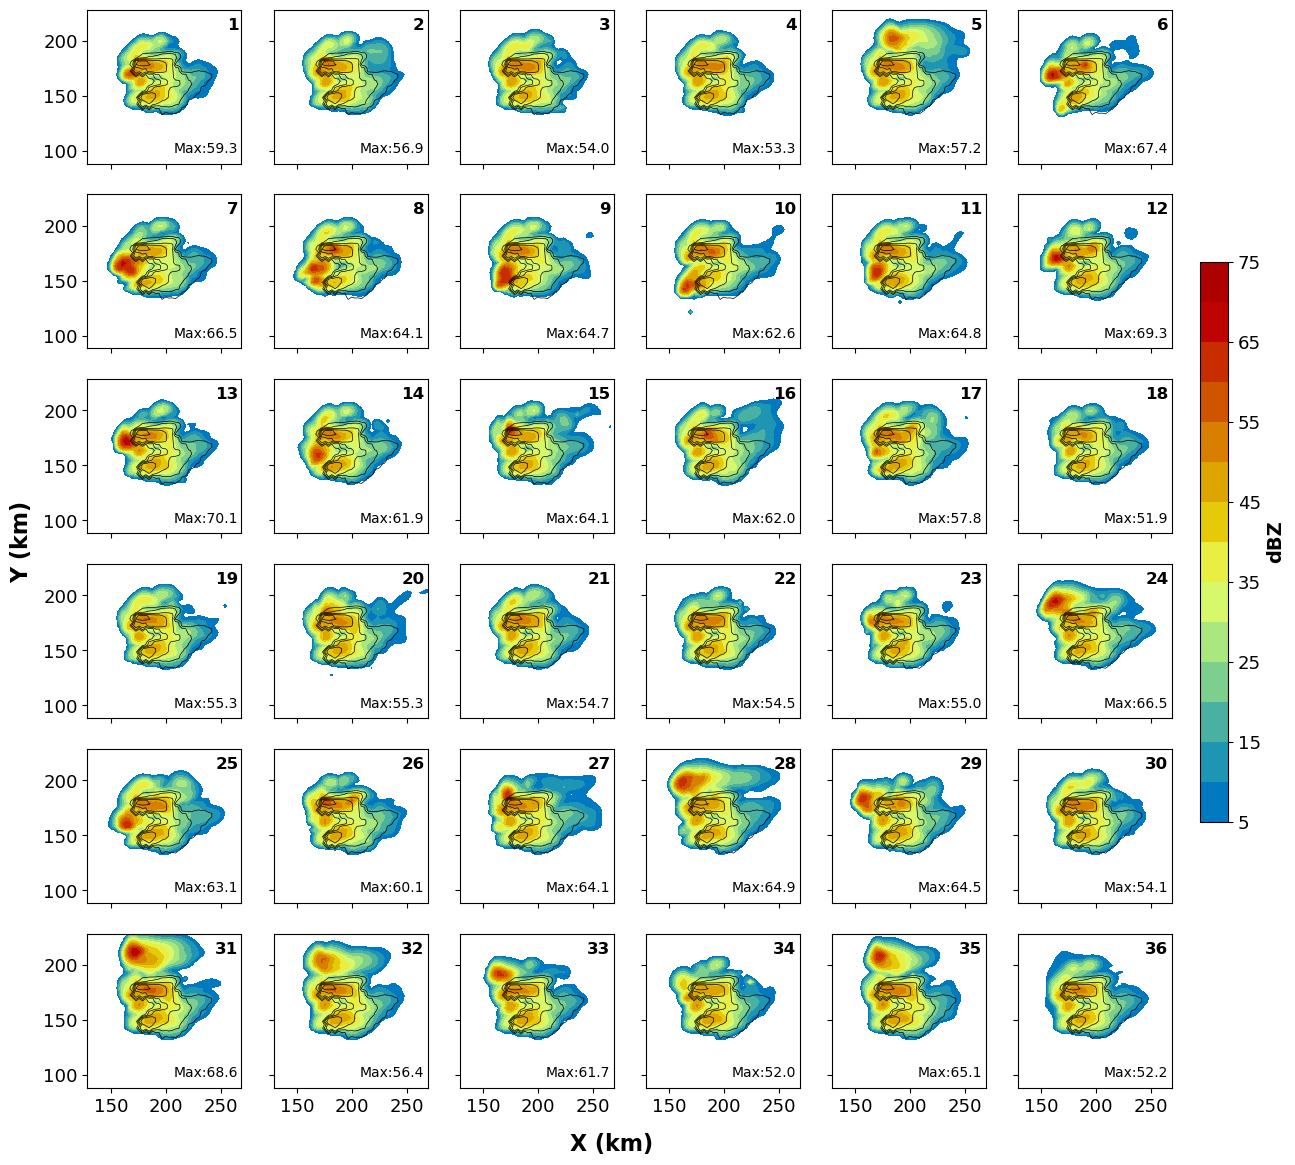

In [12]:
ne = ens_state.ne
height = 1 # in km
cref = True
obs = True
plot_width = 140 # in km 
smooth_obs = True

x = ens_state.xc[:]/1000
y = ens_state.yc[:]/1000
z = ens_state.zc[:]/1000

zi = findnearest(z, height) # if cref is chosen, this isn't used
# prepping the observations
if obs == True:
    obs_3d = ens.ens_GRID_RELECTIVITY(ens_state, cref=cref) 
    if cref == True: obs = obs_3d[0]
    else: obs = obs_3d[zi] # this data is interpolated to the model grid, so this is okay to index with zi
    if smooth_obs: obs = gaussian_filter(obs, sigma=.5)
    

nrow, ncol = subplot_format(ne)
#fig,axes = plt.subplots(nrow, ncol, figsize=(10,8), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
fig,axes = plt.subplots(nrow, ncol, figsize=(14,14), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

full_field = ens_state['DBZ'][:].sum(axis=(0,1))
yc, xc = np.where(full_field == full_field.max())

if plot_width!= None:
    axes[0,0].set_xlim(x[xc]-plot_width/2 +20, x[xc]+plot_width/2+20) # shift plot 20 km to the right, it just looks better
    axes[0,0].set_ylim(y[yc]-plot_width/2-20, y[yc]+plot_width/2 -20)

for i,ax in enumerate(axes.flatten()):
    i+=1 # 0 is the mean member, so always skip it
    
    if cref == True: dbz = ens_state['DBZ'][i,:].max(axis=0) 
    else: dbz = ens_state['DBZ'][i,zi] 
    

    im=ax.contourf(x,y, dbz, cmap=ctables.REF_default, levels=np.arange(5,80,5))    
    ax.contour(x,y, obs, colors='k', levels=np.arange(10,80,10), linewidths=0.5)
    ax.text(0.98, .05, f'Max:{dbz.max():.1f}', va='bottom',ha='right', fontsize=10, transform=ax.transAxes)
    ax.text(0.98, .95, f'{i}', ha='right', va='top',fontsize=12, transform=ax.transAxes, weight='bold')

# xwidth = (axes[0,0].get_position().x1-axes[0,0].get_position().x0)*.2
# ywidth = (axes[0,0].get_position().y1-axes[0,0].get_position().y0)*.4
# plt.subplots_adjust(hspace = ywidth, wspace = ywidth)

cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('dBZ', weight='bold')

#plt.tight_layout()

fig.text(0.5, 0.07, 'X (km)', ha='center', va='center', weight='bold', fontsize=16);
fig.text(0.07,0.5, r'Y (km)', weight='bold', va='center', fontsize=16, rotation='vertical');

In [15]:

myDTstring = '2024,05,08,19,15,00'

with open('/work/jessica.mcdonald/CM1_LETKF_2025/AllExperiments/DBZ/DBZ.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)

ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1)
ens.ens_CM1_coords(ens_state)


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 19:15:00

 ==> FindRestartFile:  Found time 0 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/AllExperiments/DBZ/member001/cm1rst_000000.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 19:15:00 


 Wallclock time for serial read netCDF ensemble files: 19.147  sec

 Wallclock time to convert from C to A grid: 0.915  sec

 Wallclock time to create ensemble means: 1.321  sec

 Wallclock time to read arrays from netCDF ensemble files: 22.163  sec

 Wallclock time to create coordinates: 0.0  sec


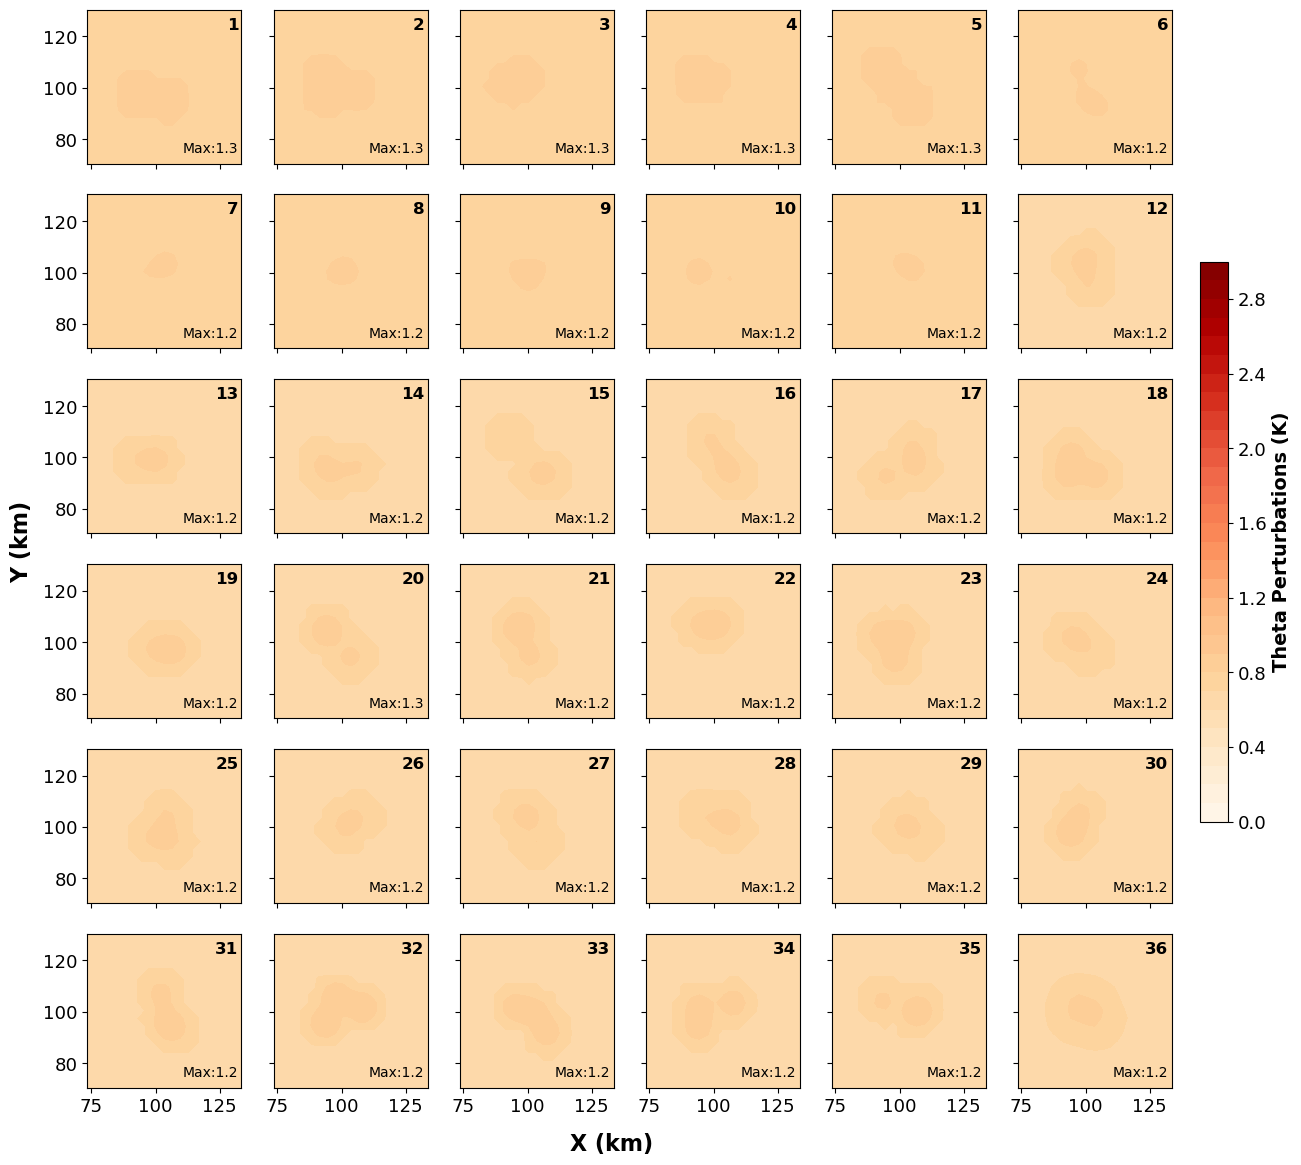

In [26]:
ne = ens_state.ne
height = 1 # in km
cref = True
obs = True
plot_width = 60 # in km 
smooth_obs = True

x = ens_state.xc[:]/1000
y = ens_state.yc[:]/1000
z = ens_state.zc[:]/1000

zi = findnearest(z, height) # if cref is chosen, this isn't used
# prepping the observations


nrow, ncol = subplot_format(ne)
#fig,axes = plt.subplots(nrow, ncol, figsize=(10,8), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
fig,axes = plt.subplots(nrow, ncol, figsize=(14,14), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

thp = ens_state['TH'][:] -ens_state['TH'][:,:,-1,0][:,:,np.newaxis, np.newaxis]

thp = ens_state['QV'][:]*50

full_field= (thp).sum(axis=(0,1))
yc, xc = np.where(full_field == full_field.max())

if plot_width!= None:
    axes[0,0].set_xlim(x[xc]-plot_width/2, x[xc]+plot_width/2) # shift plot 20 km to the right, it just looks better
    axes[0,0].set_ylim(y[yc]-plot_width/2, y[yc]+plot_width/2)

for i,ax in enumerate(axes.flatten()):
    i+=1 # 0 is the mean member, so always skip it
    
    

    im=ax.contourf(x,y, thp[i,zi,:,:],cmap='OrRd',levels=np.arange(0, 3.1, .1))    
    ax.contour(x,y, thp[i,zi,:,:], levels=np.arange(0, 3.1, .5), colors='k', linewidths=0.5, alpha=0.3)
    
    ax.text(0.98, .05, f'Max:{thp[i].max():.1f}', va='bottom',ha='right', fontsize=10, transform=ax.transAxes)
    ax.text(0.98, .95, f'{i}', ha='right', va='top',fontsize=12, transform=ax.transAxes, weight='bold')

# xwidth = (axes[0,0].get_position().x1-axes[0,0].get_position().x0)*.2
# ywidth = (axes[0,0].get_position().y1-axes[0,0].get_position().y0)*.4
# plt.subplots_adjust(hspace = ywidth, wspace = ywidth)

cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Theta Perturbations (K)', weight='bold')

#plt.tight_layout()

fig.text(0.5, 0.07, 'X (km)', ha='center', va='center', weight='bold', fontsize=16);
fig.text(0.07,0.5, r'Y (km)', weight='bold', va='center', fontsize=16, rotation='vertical');

In [77]:
h,w

(4, 5)

In [35]:
from ens import _clevels, PLOT_ONE

In [ ]:
def PLOT_ONE(mfld, x2d, y2d, map, cint=None, height=0., label = None, ax=None, counties=None, \
             cmap = None, clevels = [], **kwargs):
#
#===============================================================================
  
  if cint == None and len(clevels) > 0:
    myclevels = clevels
  else:
    myclevels = nice_clevels(mfld.min(), mfld.max(), outside=True, cint=cint, **kwargs)[3]
     
  if cmap == None:
    cmap = ens_default_cmap

  if "zoom" in kwargs:
    zoom = kwargs["zoom"]
  else:
    zoom = None

  clvls = myclevels[ myclevels != 0.0 ] 
    
  plot = map.contourf(x2d, y2d, mfld, myclevels, ax = ax, cmap=cmap)
  cbar = map.colorbar(plot, ax=ax)
  plot = map.contour(x2d, y2d, mfld, clvls[::2], colors='k', linewidths=0.5, ax=ax)
  cbar.set_label('%s' % label[0:3])
  ax.tick_params(axis='both', which='major', labelsize=10)
  ax.tick_params(axis='both', which='minor', labelsize=8)
  ax.xaxis.set_major_formatter(ticker.FuncFormatter(mtokm))
  ax.yaxis.set_major_formatter(ticker.FuncFormatter(mtokm))
  ax.set_xlabel("%s" % ('X (km)'))
  ax.set_ylabel("%s" % ('Y (km)'))
  if zoom:
      ax.set_xlim(1000.*zoom[0],1000.*zoom[1])
      ax.set_ylim(1000.*zoom[2],1000.*zoom[3])

  if label:
    cbar.set_label(label)
    title = ("%s  Height:  %4.2f km" % (label, height/1000.))
    ax.set_title(title, fontsize=12)
    
  if counties:
    mymap_draw_details(map, shape_env=None, ax=ax)
  
  at = AnchoredText("Max: %4.1f \n Min: %4.1f" % (mfld.max(),mfld.min()), loc=4, prop=dict(size=10), frameon=True,)
  at.patch.set_boxstyle("round,pad=0.,rounding_size=0.2")
  ax.add_artist(at)


 ==> ens_GRID_REFL: Number of points found from initial search:      16384
 Information about where the obs are relative to the grid...
X-GRID MIN: -178.5  X-OB MIN:  -184.9  X-OB MAX:  200.8  X-GRID MAX:  202.5
Y-GRID MIN: -178.5  Y-OB MIN:  -181.1  Y-OB MAX:  199.1  Y-GRID MAX:  202.5
Z-GRID MIN:  0.1  Z-OB MIN:   1.0  Z-OB MAX:   8.0  Z-GRID MAX:  19.7
 FORTRAN OBS_2_GRID3D:  dims           128         128          51       16384
 FORTRAN OBS_2_GRID3D:  dx, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  dy, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  vscale     2000.00000    
 FORTRAN OBS_2_GRID3D:    obs    0.00000000       48.5019989    
 FORTRAN OBS_2_GRID3D:  x-obs   -184932.531       200830.484    
 FORTRAN OBS_2_GRID3D:  y-obs   -181149.016       199139.375    
 FORTRAN OBS_2_GRID3D:  z-obs    1000.00000       8000.00000    
 FORTRAN OBS_2_GRID3D:  x-grid  -178500.000       202500.000    
 FORTRAN OBS_2_GRID3D:  y-grid  -178500.000      

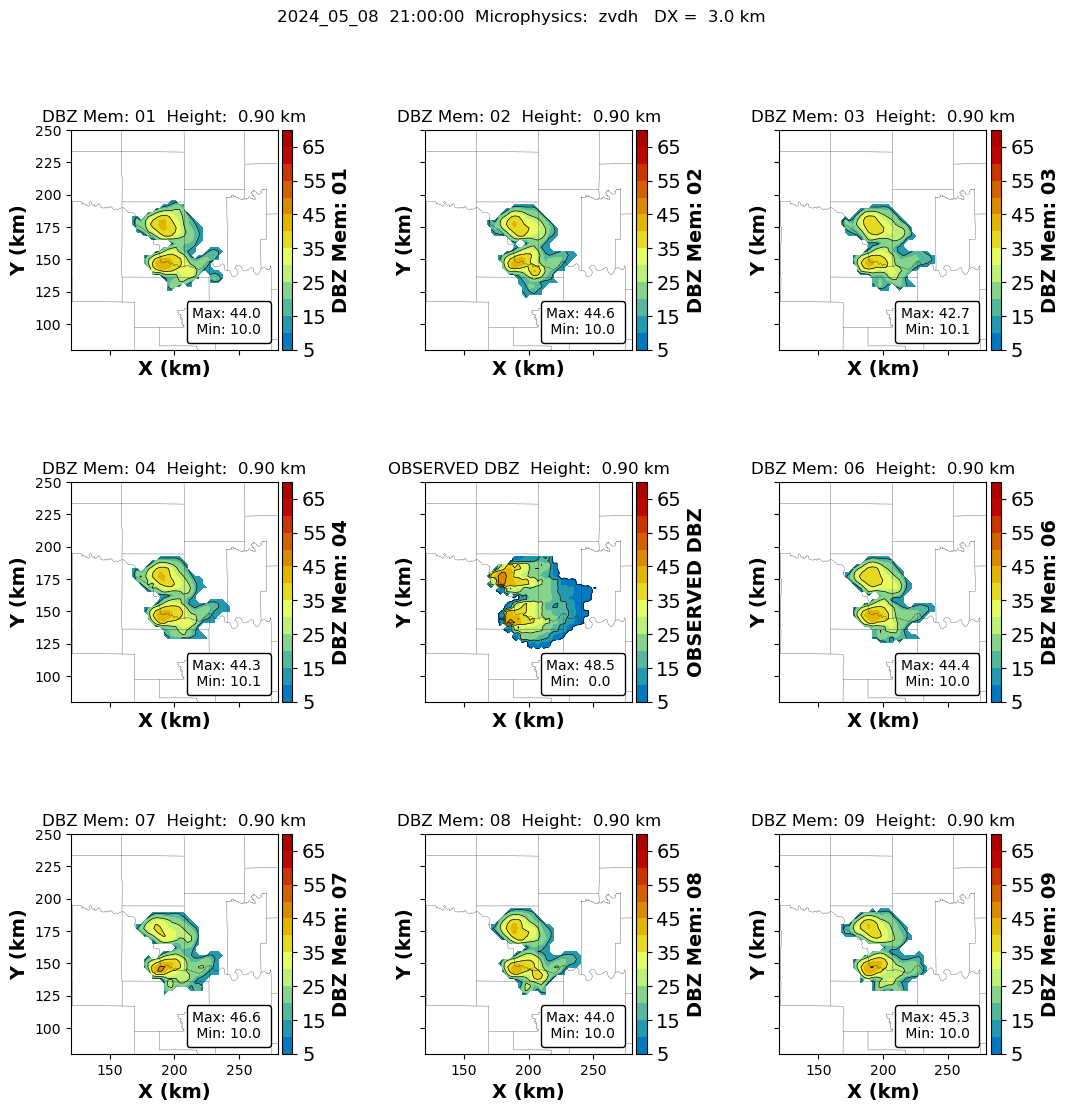

In [42]:
obs=True
cparams=None
var='DBZ'
klevel=5
zoom=False
if obs:
    f3d = ens.ens_GRID_RELECTIVITY(state, cref=False)
    print("\n --> PLOT_9PANEL:  Interpolated reflectivity")

fig, ax_grid = P.subplots(3,3, figsize=(12,12), sharex=True, sharey=True)

map = ens.mymap(fstate.xc, fstate.yc, state.lat0, state.lon0, counties=False, noticks=False)
lon2d, lat2d, x2d, y2d = map.makegrid(fstate.xc.size, fstate.yc.size, returnxy=True)

if state.ne <= 20:
    mem = N.arange(0,20,1)
elif state.ne <= 30:
    mem = N.arange(0,30,3)
elif state.ne <= 40:
    mem = N.arange(0,36,4)
elif state.ne <= 50:
    mem = N.arange(0,45,5)
else:
    mem = N.arange(0,54,6)
 
if cparams == None:
    cparams = _clevels[var]

clevels = N.arange(cparams[0], cparams[1], cparams[2])

for n, ax in enumerate(ax_grid.ravel()):

    if n == 4 and obs:
        mfld = N.ma.masked_less_equal(f3d[5,:,:], 0.0)
        label = "OBSERVED DBZ"
        PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=state.zc[5], label = label, ax = ax, \
               counties=True, cmap=ctables.REF_default, zoom = zoom)
    else:
        print("\n Plotting member %d" % (mem[n]+1))
        if var == "DBZ":
            mfld = N.ma.masked_less_equal(state['DBZ'][:][mem[n],klevel,:,:], 10.)
            label = "DBZ Mem: %2.2d" % (mem[n]+1)
            PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=state.zc[klevel], label = label, ax = ax, \
               counties=True, cmap=ctables.REF_default, zoom = zoom)
        else:
            if var == "THP":
                mfld = N.clip(state['TH'][:][mem[n],klevel,:,:] - state['TH'][:][mem[n],klevel,-1,1], cparams[0],cparams[1])
            elif var == "WZ":
                mfld = 10000.*ComputeWZ(fstate.xc, fstate.yc, fstate.u[mem[n],klevel], fstate.v[mem[n],klevel])
            else:
                mfld = N.clip(state[var][mem[n],klevel,:,:],cparams[0],cparams[1])
                
                label = "%s Mem: %2.2d" % (var,mem[n]+1)
                PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=state.zc[klevel], label = label, ax = ax, \
                   counties=True, cmap=ens_default_cmap, zoom = zoom)
            
    dx = state.xc[2] - state.xc[1]
    title = ("%s  Microphysics:  %s   DX = %4.1f km" % (state.datetime[0].strftime("%Y_%m_%d  %H:%M:%S"),state.experiment['microphysics'],
                   dx/1000.))
    fig.suptitle(title, fontsize=12)

for ax in ax_grid.flatten():
    ax.set_xlim(120*1000, 280*1000)
    ax.set_ylim(80*1000, 250*1000)

plt.subplots_adjust(hspace=0.6, wspace=0.6)

In [9]:
def ens_GRID_RELECTIVITY(ens, ob_file=None, plot=False, cref=True):
#
#===============================================================================

  t0 = timer()

# These values are set in the experiment dictionary created at the begining of the run

  hradius = ens.experiment['ADD_NOISE']['hradius']
  vradius = ens.experiment['ADD_NOISE']['vradius']
  xoffset = ens.experiment['xoffset']
  yoffset = ens.experiment['yoffset']
  glat    = ens.experiment['lat0']
  glon    = ens.experiment['lon0']
  
# if ob_file == None, use experiment radar file

  if ob_file == None:
    ob_file = ens.experiment['radar_obs']

  ob_f = pyDart.pyDART()
  ob_f.file(ob_file)

# look for reflectivity +/- 2.5 min 

  analysis_time = ens.datetime[0]
  dt            = datetime.timedelta(0,300)
  begin         = analysis_time - dt/2
  ending        = analysis_time + dt/2

  print("\n ==> ens_GRID_REFL: Using pyDart to search with begin time of: ", begin.strftime("%Y-%m-%d %H:%M:%S"))
  print("\n ==> ens_GRID_REFL: Using pyDart to search with end   time of: ", ending.strftime("%Y-%m-%d %H:%M:%S"))
 
  ob_f.search(start=begin.timetuple()[:6], end=ending.timetuple()[:6], condition = '(kind == 12) & (value > 0.) & (z < 10000.)')

# number of observations, if there are none, stop program, something is wrong

  if len(ob_f.index) >= 50:
    print("\n  ==> ens_GRID_REFL:  Total number of obs found at search time: %s \n" % len(ob_f.index))
  else:
    print("\n  ==> ens_GRID_REFL:  Insufficient number of obs (<=50) found at search time:  %d obs \n" % (len(ob_f.index)))
    return 'None'

# using the search index generated from above, obtain the location, data, and type

  odata = ob_f.get_data()
  
  data    = odata['value'][:]
  lats    = odata['lat'][:]
  lons    = odata['lon'][:]
  hgts    = odata['height'][:]

  print("\n ==> ens_GRID_REFL: Number of points found from initial search:      %d" % (data.size))

# The coordinate system here is based on the grid lat0/lon0/hgt0, and the offset grid stored in fstate
#     ens stores the x/y grid in grid-internal coordinates

  map      = mymap(fstate.xc, fstate.yc, glat, glon)
  xob, yob = map(lons, lats)
  xob, yob = xob+xoffset, yob+yoffset

# The coordinate system here is based on the grid lat0/lon0/hgt0, and the offset grid stored in fstate
#     ens stores the x/y grid in grid-internal coordinates

# sw_lat, sw_lon = dxy_2_dll(fstate.xc.min(), fstate.yc.min(), glat, glon, degrees=True)
# ne_lat, ne_lon = dxy_2_dll(fstate.xc.max(), fstate.yc.max(), glat, glon, degrees=True)
    
# p1 = Proj(proj='lcc', ellps='WGS84', datum='WGS84', lat_1=_truelat1, lat_2=_truelat2, \
#                        lat_0=0.5*(ne_lat+sw_lat), lon_0=0.5*(ne_lon+sw_lon))
                         
# xob, yob = p1(lons, lats, errchk = True)
# xob, yob = xob+xoffset, yob+yoffset

  print(" Information about where the obs are relative to the grid...")
  print("X-GRID MIN: %4.1f  X-OB MIN:  %4.1f  X-OB MAX:  %4.1f  X-GRID MAX:  %4.1f" % \
          (0.001*fstate.xc.min(), 0.001*xob.min(),  0.001*xob.max(), 0.001*fstate.xc.max()))
  print("Y-GRID MIN: %4.1f  Y-OB MIN:  %4.1f  Y-OB MAX:  %4.1f  Y-GRID MAX:  %4.1f" % \
          (0.001*fstate.yc.min(), 0.001*yob.min(),  0.001*yob.max(), 0.001*fstate.yc.max()))
  print("Z-GRID MIN: %4.1f  Z-OB MIN:  %4.1f  Z-OB MAX:  %4.1f  Z-GRID MAX:  %4.1f" % \
          (0.001*fstate.zc.min(), 0.001*hgts.min(),  0.001*hgts.max(), 0.001*fstate.zc.max()))

# Create obs list for KDTree query...

  xyz_obs  = N.vstack((hgts,yob,xob))
  obs_list = list(xyz_obs.transpose())

# If needed, here is some fake data for testing code

# xob, yob, hgts = [xoffset+0.5*(fstate.xc.max()-fstate.xc.min())], [yoffset+0.5*(fstate.yc.max()-fstate.yc.min())], [2000.]
# xyz_obs  = N.vstack((hgts,yob,xob))
# obs_list = list(xyz_obs.transpose())
# data = 50.*N.ones((1,))   # single point of 50 dbz
# print(data, obs_list)

# Create 3D grid arrays for KDTree
  
  y_array, z_array, x_array = N.meshgrid(fstate.yc, fstate.zc, fstate.xc)
  xyz_grid = N.dstack([z_array.ravel(),y_array.ravel(),x_array.ravel()])[0]
  
# Use cKDTree to create fast indexing for 3D grid....

  mytree = scipy.spatial.cKDTree(xyz_grid)
  distance, indices1D = mytree.query(obs_list)

# these are the integer indices that you now pass into the fortran routine. They
# are the un-raveled 3D index locations nearest the observation point in the 3D array

  kk,jj,ii = N.unravel_index(indices1D, (len(fstate.zc), len(fstate.yc), len(fstate.xc)))

# for n in N.arange(data.size):
#     print("obs#: %d  Zobs:  %8.1f  Zarray:  %8.1f" % (n, xyz_obs[0,n], z_array[kk[n],jj[n],ii[n]]))
#     print("obs#: %d  Yobs:  %8.1f  Yarray:  %8.1f" % (n, xyz_obs[1,n], y_array[kk[n],jj[n],ii[n]]))
#     print("obs#: %d  Xobs:  %8.1f  Xarray:  %8.1f\n" % (n, xyz_obs[2,n], x_array[kk[n],jj[n],ii[n]]))
    
# Call the fortran routine that grids the dbz data

  dbz3d = obs_2_grid3d(data, xob, yob, hgts, x_array, y_array, z_array, ii, jj, kk, 4000., 2000., 0.0)

  print("\n ==> ens_GRID_REFL: 3D gridded DBZ:   Max:  %4.1f   Min:  %4.1f" % (dbz3d.max(), dbz3d.min()))

# Create composite reflectivity, and then replicate it into a 3D array
  
  dbz2d = N.zeros((1,))

  if cref:

    dbz2d = dbz3d.max(axis=0)
  
    for k in N.arange(ens.nz):
      dbz3d[k] = dbz2d
      
    print("\n ==> ens_GRID_REFL: 2D composite DBZ requested   Max:  %4.1f   Min:  %4.1f" % (dbz2d.max(), dbz2d.min()))
   
  del xyz_obs, x_array, y_array, z_array, xyz_grid, mytree
             
  return dbz3d

(80000.0, 250000.0)

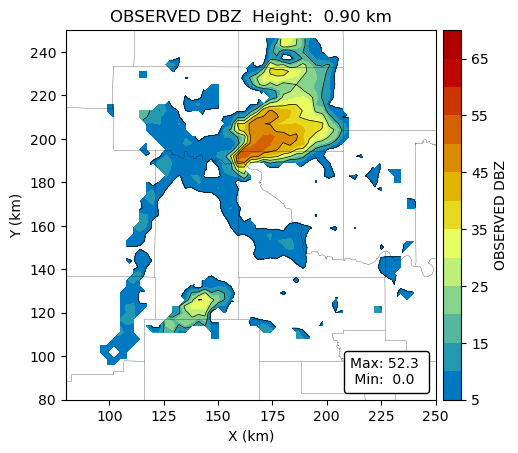

In [25]:
fig,ax=plt.subplots(1)
mfld = N.ma.masked_less_equal(f3d[5,:,:], 0.0)
label = "OBSERVED DBZ"
PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=state.zc[5], label = label, ax = ax, \
       counties=True, cmap=ctables.REF_default, zoom = zoom)
ax.set_xlim(80*1000, 250*1000)
ax.set_ylim(80*1000, 250*1000)

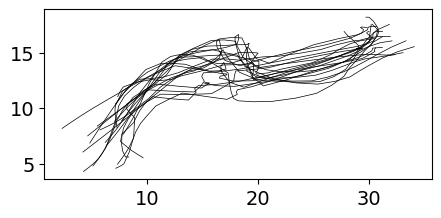

In [16]:
t=10
fig=plt.figure(figsize=(5,5))
ax = plt.gca()
ax.set_aspect('equal')
for mem in np.arange(1,21,1):
    #try:
    cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{mem:03d}/cm1rst_{t:06d}.nc',decode_timedelta= True)
   
    
    ax.plot(cm1.ua[0,:30,0,-1],cm1.va[0,:30,0,-1],lw=0.5, color='k' )
    #ax.plot(cm1.theta[0,:30,0,-1],cm1.zh[:30],lw=0.5, color='k' )
    cm1.close()
    

# modifying warm bubble code

In [107]:
#import datetime as dt
import cftime 
from datetime import datetime as py_datetime

import time
import datetime
from datetime import datetime as py_datetime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import ens

# from contextlib import redirect_stdout
# import io
def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

import netCDF4 as ncdf
import numpy as N
import math as M
import glob
import sys
import os
import re

import matplotlib
import matplotlib.pyplot as P
from matplotlib import ticker
from matplotlib.offsetbox import AnchoredText

import json
from pyproj import Proj
from time import time as timer
from pyDart import dll_2_dxy, dxy_2_dll
import pyDart
import datetime
from subprocess import *
#from cbook2 import *
import ctables
from optparse import OptionParser
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial

from mpl_toolkits.basemap import Basemap

from fsrc.fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fsrc.fpython2 import add_smooth_perts
#import fsrc.recursive2d as recursive2d

import state_vector as state

from ens import read_CM1_ens

def fnormal(prng=N.random, scale=1.0, size=(1,)):
  return prng.normal(scale=scale, size=size)

def funiform(prng=N.random, scale=1.0, size=(1,)):
    return scale*(0.5 - prng.uniform(size=size))

In [15]:

np.random.seed(r_seed)
rand_nums = (np.random.rand(nb,2,ens_state.ne)*2)-1

In [110]:
experiment = 'AllExperiments/DBZ'
myDTstring = '2024,05,08,19,15,00'

with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/{experiment}/DBZ.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)

ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1)
ens.ens_CM1_coords(ens_state)


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 19:15:00


  ERROR!!!

 ==>!! FindRestartFile: A file with the restart time of 84000 cannot be found, exiting!!!


  ERROR!!!


SystemExit: -1

/home/jessica.mcdonald/miniconda3/envs/letkf_env/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [20]:
def ens_IC_warm_bubble(ens_state, plot=False, writeout=False):

# These values are set in the experiment dictionary created at the begining of the run

  nb           = ens_state.experiment['INIT']['nb']
  wpert        = ens_state.experiment['INIT']['wpert']
  upert        = ens_state.experiment['INIT']['upert']
  vpert        = ens_state.experiment['INIT']['vpert']
  tpert        = ens_state.experiment['INIT']['tpert']
  tdpert       = ens_state.experiment['INIT']['tdpert']
  qvpert       = ens_state.experiment['INIT']['qvpert']
  centerx      = ens_state.experiment['INIT']['centerx']
  centery      = ens_state.experiment['INIT']['centery']
  max_x_offset = ens_state.experiment['INIT']['max_x_offset']
  max_y_offset = ens_state.experiment['INIT']['max_y_offset']
  zbmin        = ens_state.experiment['INIT']['zbmin']
  zbmax        = ens_state.experiment['INIT']['zbmax']
  bhrad        = ens_state.experiment['INIT']['rbubh']
  bvrad        = ens_state.experiment['INIT']['rbubv']
  r_seed       = ens_state.experiment['INIT']['r_seed']

  print(upert, wpert, vpert, tpert, tdpert)

  klevel      = 4   # level to plot perturbations
  me          = int(ens_state.ne/2)  # which member to plot

  np.random.seed(r_seed)
  xypert = (np.random.rand(nb,2,ens_state.ne)*2)-1

  for n in np.arange(ens_state.ne):

      xb = centerx + xypert[:,0,n]*max_x_offset # these are length nb
      yb = centery + xypert[:,1,n]*max_y_offset
      zb = zbmax*np.ones(xb.shape) + ens_state.hgt
      
      ni, nj, nk = ens_state['nx'],ens_state['ny'],ens_state['nz']
      xh= np.tile(ens_state['xc'][:], (nj*nk,1)).reshape(nk, nj, ni)
      yh= np.tile(ens_state['yc'][:], (ni*nk,1)).reshape(nk, nj, ni).swapaxes(1,2) 
      zh= ens_state['zc'][:, np.newaxis, np.newaxis]
      
      pert = np.zeros([nk,nj,ni])
      
      for b in range(nb): # this uses the equation from CM1 to create the warm bubbles
          beta = np.sqrt( ((xh- xb[b])/bhrad)**2 + ((yh- yb[b])/bhrad)**2 + ((zh - zb[b])/bvrad)**2 )
          mask = beta < 1
          pert[mask]+= (np.cos(0.5*np.pi*beta[mask])**2)
  
      pospert = (pert - pert.min()) / (pert.max()-pert.min())
      neupert = 0.5 - pospert
      
      print("\n ==> ens_IC_warm_bubble: NE:  %d  NegPert_Min:  %f  NegPert_Max:  %f" % (n, neupert.min(), neupert.max()))
      print("\n ==> ens_IC_warm_bubble: NE:  %d  PosPert_Min:  %f  PosPert_Max:  %f" % (n, pospert.min(), pospert.max()))
      
      if tpert > 0.0:
          ens_state['TH'][n] = ens_state['TH'][n] + tpert*pospert
      if wpert > 0.0:
          ens_state['W'][n]  = ens_state['W'][n]  + wpert*pospert        
      if upert > 0.0:
          ens_state['U'][n]  = ens_state['U'][n]  + upert*neupert
      if vpert > 0.0:
          ens_state['V'][n]  = ens_state['V'][n]  + vpert*neupert
  
      if tdpert > 0.0 and qvpert < 0.01:                                  # Dont do both, prefer saturations...
          p0 = 1000.*(ens_state['PI0'][n])**3.508
          e  = ens_state['QV'][n]*p0/(0.622+ens_state['QV'][n])                       # vapor pressure
          e  = np.clip(e, 0.001, 100.)                                     # avoid problems near zero
          td = 273.16 + ( 243.5 / ( 17.67/np.log(e/6.112) - 1.0 ) )        # Bolton's approximation
          td = np.clip(td + tdpert*pospert, 200.0, (p0*ens_state['TH'][n])-0.1)  # make sure Td is < T
      
          # Transform back
          tdc = td - 273.16
          e   = 6.112 * np.exp(17.67*tdc / (tdc+243.5) )                   # Bolton's approximation
          ens_state['QV'][n] = 0.622*e / (p0-e)
      
      # If qvpert > 0, essentially saturate the regions where the warm bubbles are.
      if qvpert > 0.0:
          tc = (ens_state['PI0'][n]*ens_state['TH'][n]) - 273.16
          p0 = 1000.*(ens_state['PI0'][n])**3.508
          e  = 6.112 * np.exp(17.67*tc / (tc+243.5) )  
          qvs = (0.622*e)/ (p0-e)      
          ens_state['QV'][n] = np.where(pospert > 0.0, (100.-qvpert)*qvs/100., ens_state['QV'][n])

# Write ensemble back out
  if writeout:
    write_CM1_ens(ens_state, writeEns=True, writeFcstMean=True, overwrite=True)

In [90]:
0.6e9

600000000.0

In [71]:
nb           = ens_state.experiment['INIT']['nb']
wpert        = ens_state.experiment['INIT']['wpert']
upert        = ens_state.experiment['INIT']['upert']
vpert        = ens_state.experiment['INIT']['vpert']
tpert        = ens_state.experiment['INIT']['tpert']
tdpert       = ens_state.experiment['INIT']['tdpert']
qvpert       = ens_state.experiment['INIT']['qvpert']
centerx      = ens_state.experiment['INIT']['centerx']
centery      = ens_state.experiment['INIT']['centery']
max_x_offset = ens_state.experiment['INIT']['max_x_offset']
max_y_offset = ens_state.experiment['INIT']['max_y_offset']
zbmin        = ens_state.experiment['INIT']['zbmin']
zbmax        = ens_state.experiment['INIT']['zbmax']
bhrad        = ens_state.experiment['INIT']['rbubh']
bvrad        = ens_state.experiment['INIT']['rbubv']
r_seed       = ens_state.experiment['INIT']['r_seed']

In [78]:
var = thp
varnorm = (thp - thp.max()) / (thp.min() - thp.max())

for i, var in enumerate([thp, qvp, w]):
    varnorm = (thp - thp.max()) / (thp.min() - thp.max())
    axes[i,0].contourf(x,y, varnorm, cmap = 'Reds', levels=np.arange(0, 1.1, .1))

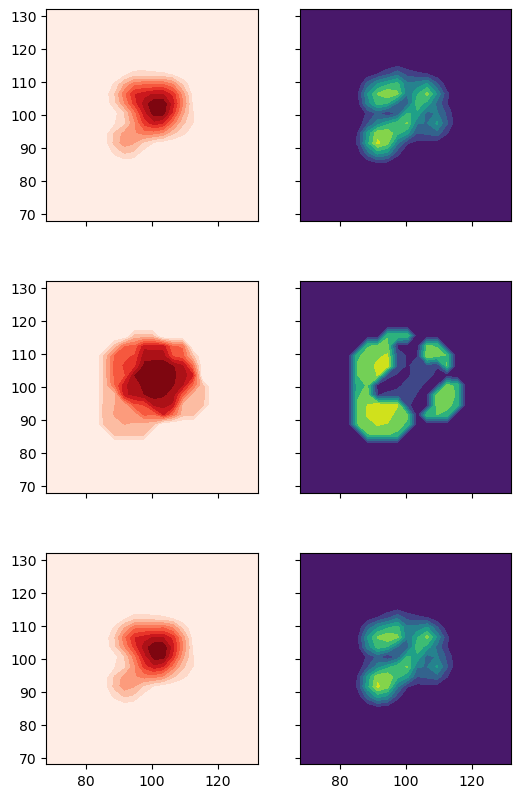

In [99]:
# buf_km = 40
# buf = int(np.ceil((buf_km*1000)/ens_state['dx']))# 
# cx = findnearest()

member = 3

fig, axes = plt.subplots(3,2, figsize=(6,10), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
x,y = ens_state['xc'][:]/1000,ens_state['yc'][:]/1000
axes[0,0].set_xlim((centery-(max_x_offset*4))/1000, (centery+(max_x_offset*4))/1000)
axes[0,0].set_ylim((centery-(max_y_offset*4))/1000, (centery+(max_y_offset*4))/1000)


thp = ens_state['TH'][:, klevel,:,:] - ens_state['TH'][:, klevel,0,-1][:,np.newaxis, np.newaxis]
qvp = 1000*( ens_state['QV'][:, klevel,:,:] - ens_state['QV'][:, klevel,0,-1][:,np.newaxis, np.newaxis])
w   = ens_state['W'][:, klevel,:,:]

# raw output from a single member
# axes[0,0].contourf(x,y,thp, levels = np.arange(-1*tpert, tpert+.1, .1), cmap='RdBu_r')
# axes[1,0].contourf(x,y,qvp, levels = np.arange(-1*qvpert, qvpert+.1, .1), cmap='RdBu_r')
# axes[2,0].contourf(x,y,w  , levels = np.arange(-1*wpert, wpert+.1, .1), cmap='RdBu_r')

for i, var in enumerate([thp, qvp, w]):
    varnorm = (var[member] - var[member].max()) / (var[member].min() - var[member].max())
    varstd = np.std(var, axis=0)
    axes[i,0].contourf(x,y, varnorm, cmap = 'Reds_r', levels=np.arange(0, 1.1, .1))
    axes[i,1].contourf(x,y, varstd)

In [105]:
import datetime as dt
base_dir = "AllExperiments/DBZ"  # name/location of the directory where all of your model output will go (it doesn't need to already exist)

nthreads = 8            # number of threads for run_filter.py (the actual DA)
ncores   = 64           # the number of cores that CM1 will use to run in run_fcst.py

init_sounding = "run_soundings"    # location of soundings for each ensemble (sounding name should match ensemble name (i.e. member 001 gets init_sounding/Run01Sounding.txt for input_sounding))
obs_loc = 'Obs/8may24_cm1_obs.csv' # location of radar files
obs_inc = [ 'DBZ']            # options: VR, DBZ, or all (for any available data in data file). 
                                   # Add soon: CA for clear air (?). Let's you control what's being assimilated. Given to run_filter.py and implemented in computeHx.py

cook_period       = 45      # time in minutes, amount of time to let CM1 run before DA starts
assimilation_freq = 5       # time in minutes, cycling interval
forecast_length   = 30      # time in minutes, amount of time to run CM1 after DA cycling completes  

DA_start_time = dt.datetime(2024, 5, 8, 20)    # time that DA will start
DA_end_time   = dt.datetime(2024, 5, 8, 21)    # time that DA will end (inclusive; DA will occur/an analysis file will be produced for this time step too)


run_setup     = True               # set this to false if you have already run the cook period (or already have those files) and ONLY want to do a DA experiment 
make_plots    = True               # if you want to make the summary plots at the end (these need work... lolz)

#################################################################### 
#################################################################### 

name = base_dir.split('/')[-1]
exp_name = f'{base_dir}/{name}.exp'

In [106]:
exp_name

'AllExperiments/DBZ/DBZ.exp'

In [3]:
ens_state = ens_state_base
ens_state

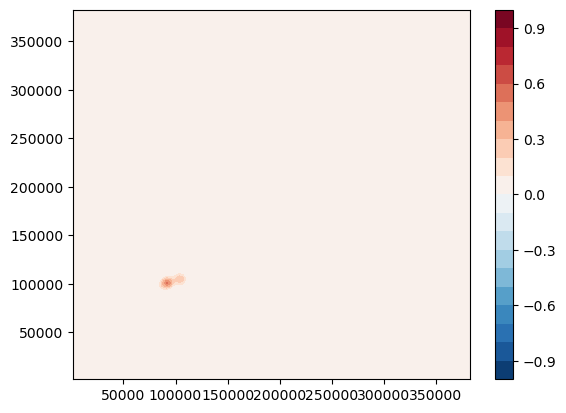

In [43]:
plt.contourf(ens_state['xc'][:], ens_state['yc'][:],  pospert[3], cmap='RdBu_r', levels=np.arange(-1,1.1,.1))

# plt.xlim(xbmin-10000, xbmax+15000)
# plt.ylim(ybmin-15000, ybmax+10000)
plt.colorbar()

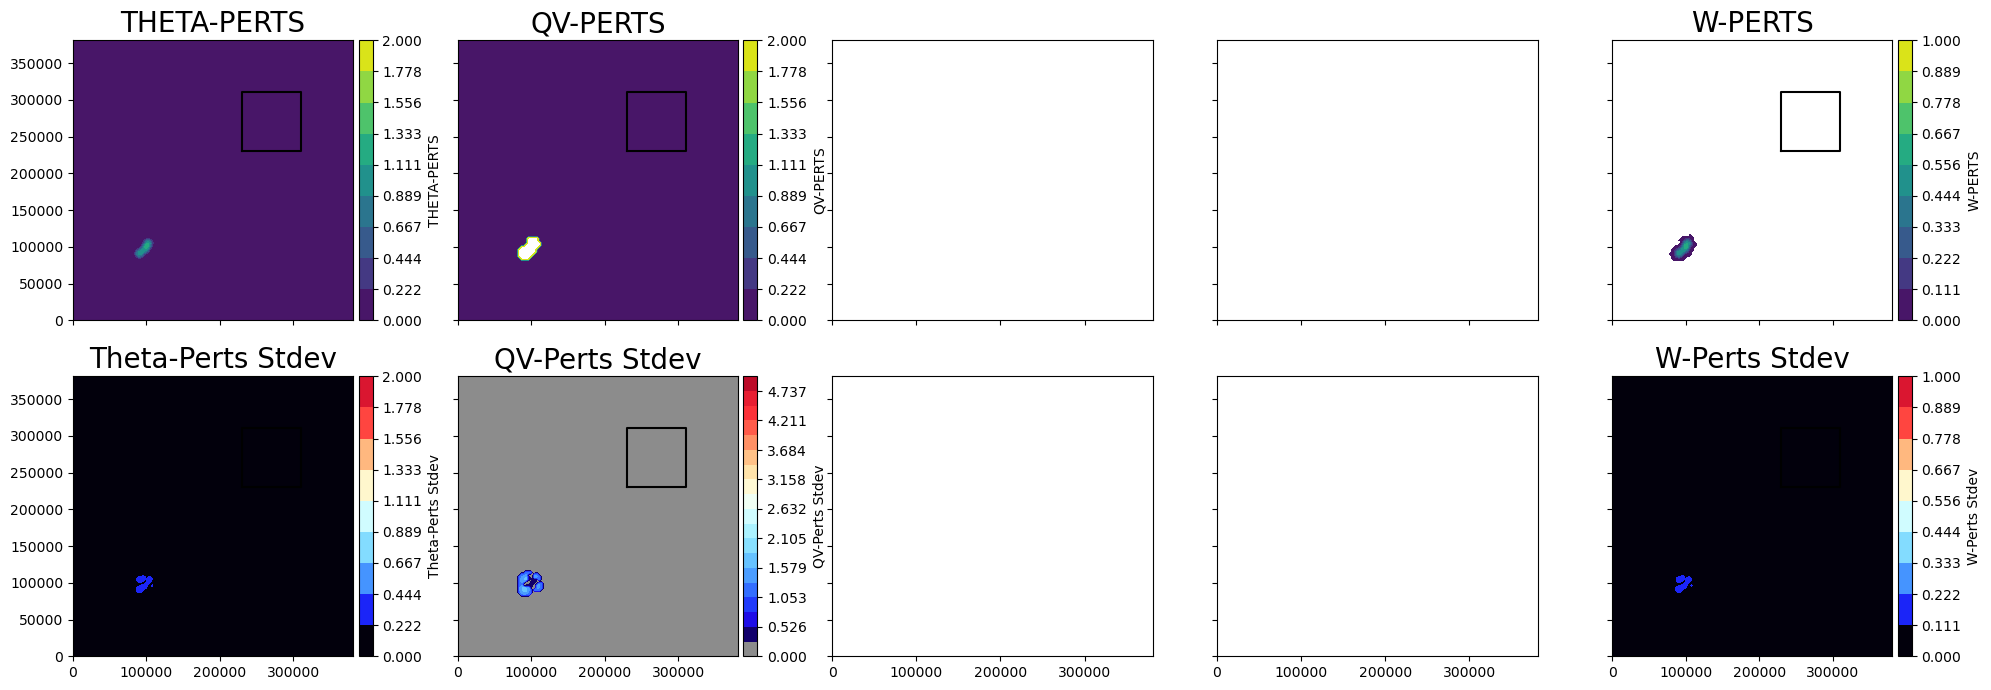

In [19]:
import ens as enspy
ens = ens_state


nb     = ens_state.experiment['INIT']['nb']
wpert  = ens_state.experiment['INIT']['wpert']
upert  = ens_state.experiment['INIT']['upert']
vpert  = ens_state.experiment['INIT']['vpert']
tpert  = ens_state.experiment['INIT']['tpert']
tdpert = ens_state.experiment['INIT']['tdpert']
qvpert = ens_state.experiment['INIT']['qvpert']

centerx = 90000
centery = 90000
max_x_offset = 8000
max_y_offset = 8000

zbmax  = ens_state.experiment['INIT']['zbmax']
bhrad  = ens_state.experiment['INIT']['rbubh'] # horizontal radius of bubble
bvrad  = ens_state.experiment['INIT']['rbubv'] # vertical radius of bubble
#bbleT  = ens_state.experiment['INIT']['bbletype']
r_seed = ens_state.experiment['INIT']['r_seed']

klevel      = 4   # level to plot perturbations
me          = int(ens_state.ne/2)  # which member to plot

xbox = N.array((centerx-40000, centerx-40000, centerx+40000, centerx+40000, centerx-40000)) - ens.experiment['xoffset']
ybox = N.array((centery-40000,centery+40000, centery+40000, centery-40000, centery-40000)) - ens.experiment['yoffset']

plot=True
if plot:

    fig, ((ax1, ax2, ax3, ax4, ax5), (ax6, ax7, ax8, ax9, ax10)) = P.subplots(2, 5, figsize=(24,8), sharex=True, sharey=True)

    map = enspy.mymap(fstate.xc, fstate.yc, ens.lat0, ens.lon0, noticks=False, counties=True)
    lon2d, lat2d, x2d, y2d = map.makegrid(fstate.xc.size, fstate.yc.size, returnxy=True)

    if tpert > 0:
        plot = map.contourf(x2d, y2d, ens['TH'][me,klevel,:,:] - ens['TH'][me,klevel,-1,-1], np.linspace(0.0, tpert, num=10), \
                            ax = ax1)
        cbar = map.colorbar(plot, ax=ax1)
        map.plot(xbox, ybox, color='k', ax=ax1)
        cbar.set_label('THETA-PERTS')
        ax1.set_title('THETA-PERTS', fontsize=20)

        # plot std-dev

        tstd = ens['TH'][:,klevel,:,:].std(axis=0)
        plot = map.contourf(x2d, y2d, tstd, np.linspace(0.0,tpert,num=10), cmap=ctables.Not_PosDef_Default, ax=ax6)
        cbar = map.colorbar(plot, ax=ax6)
        map.plot(xbox, ybox, color='k', ax=ax6) 
        cbar.set_label('Theta-Perts Stdev')
        ax6.set_title('Theta-Perts Stdev', fontsize=20)

    if qvpert > 0:
        plot = map.contourf(x2d, y2d, 1000.*(ens['QV'][me,klevel,:,:]-ens['QV'][me,klevel,-1,-1]), np.linspace(0.0, 2.0, num=10), \
                            ax=ax2)
        cbar = map.colorbar(plot, ax=ax2)
        map.plot(xbox, ybox, color='k', ax=ax2)
        cbar.set_label('QV-PERTS')
        ax2.set_title('QV-PERTS', fontsize=20)

        # plot std-dev

        tstd = 1000.*ens['QV'][:,klevel,:,:].std(axis=0)
        plot = map.contourf(x2d, y2d, tstd, np.linspace(0.0,qvpert,num=20), cmap=ctables.Not_PosDef_Default, ax=ax7)
        cbar = map.colorbar(plot, ax=ax7)
        map.plot(xbox, ybox, color='k', ax=ax7) 
        cbar.set_label('QV-Perts Stdev')
        ax7.set_title('QV-Perts Stdev', fontsize=20)

    if upert > 0.0:
        plot = map.contourf(x2d, y2d,ens['U'][me,klevel,:,:]-ens['U'][me,klevel,-1,-1], np.linspace(-upert, upert, num=10), ax=ax3)
        cbar = map.colorbar(plot, ax=ax3)
        map.plot(xbox, ybox, color='k', ax=ax3)   
        cbar.set_label('U-PERTS')
        ax3.set_title('U-PERTS', fontsize=20)

        # plot std-dev

        tstd = ens['U'][:,klevel,:,:].std(axis=0)
        plot = map.contourf(x2d, y2d, tstd, np.linspace(0.0,vpert,num=10), cmap=ctables.Not_PosDef_Default, ax=ax8)
        cbar = map.colorbar(plot, ax=ax8)
        map.plot(xbox, ybox, color='k', ax=ax8) 
        cbar.set_label('U-Perts Stdev')
        ax8.set_title('U-Perts Stdev', fontsize=20)

    if vpert > 0.0:
        plot = map.contourf(x2d, y2d,ens['V'][me,klevel,:,:]-ens['V'][me,klevel,-1,-1], np.linspace(-vpert, vpert, num=10), ax=ax4)
        cbar = map.colorbar(plot, ax=ax4)
        map.plot(xbox, ybox, color='k', ax=ax4) 
        cbar.set_label('V-PERTS')
        ax4.set_title('V-PERTS', fontsize=20)
     
        # plot std-dev

        tstd = ens['V'][:,klevel,:,:].std(axis=0)
        plot = map.contourf(x2d, y2d, tstd, np.linspace(0.0,vpert,num=10), cmap=ctables.Not_PosDef_Default, ax=ax9)
        cbar = map.colorbar(plot, ax=ax9)
        map.plot(xbox, ybox, color='k', ax=ax9) 
        cbar.set_label('V-Perts Stdev')
        ax9.set_title('V-Perts Stdev', fontsize=20)

    if wpert > 0.0:
        plot = map.contourf(x2d, y2d,ens['W'][me,klevel,:,:]-ens['W'][me,klevel,-1,-1], np.linspace(0.0, wpert, num=10), ax=ax5)
        cbar = map.colorbar(plot, ax=ax5)
        map.plot(xbox, ybox, color='k', ax=ax5) 
        cbar.set_label('W-PERTS')
        ax5.set_title('W-PERTS', fontsize=20)

        # plot std-dev

        tstd = ens['W'][:,klevel,:,:].std(axis=0)
        plot = map.contourf(x2d, y2d, tstd, np.linspace(0.0,wpert,num=10), cmap=ctables.Not_PosDef_Default, ax=ax10)
        cbar = map.colorbar(plot, ax=ax10)
        map.plot(xbox, ybox, color='k', ax=ax10) 
        cbar.set_label('W-Perts Stdev')
        ax10.set_title('W-Perts Stdev', fontsize=20)

    P.savefig("IC3D.pdf",dpi=300)

    P.show()

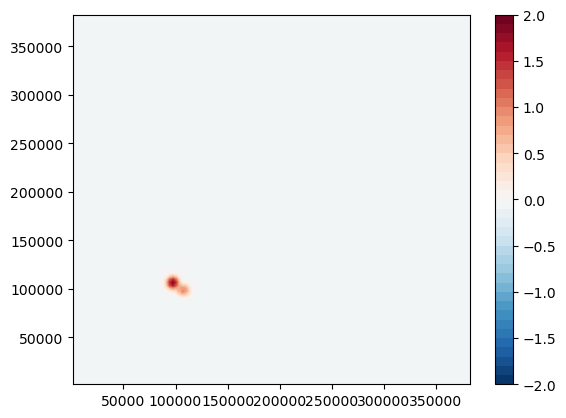

In [96]:
th = ens_state['TH'][:]
x,y,z = ens_state['xc'][:],ens_state['yc'][:],ens_state['zc'][:]
z

mem = 0
zi = findnearest(z, 1000)

plt.contourf(x,y,th[mem,zi,::]-th[mem,zi,0,-1], cmap='RdBu_r', levels=np.arange(-2,2.1,.1))
plt.colorbar()

In [62]:
def ens_IC_pert_from_box(ens, plot=False, writeout=False):

# These values are set in the experiment dictionary created at the begining of the run

  nb     = ens.experiment['IC_BOX']['nb']
  wpert  = ens.experiment['IC_BOX']['wpert']
  upert  = ens.experiment['IC_BOX']['upert']
  vpert  = ens.experiment['IC_BOX']['vpert']
  tpert  = ens.experiment['IC_BOX']['tpert']
  tdpert = ens.experiment['IC_BOX']['tdpert']
  qvpert = ens.experiment['IC_BOX']['qvpert']
  xbmin  = ens.experiment['IC_BOX']['xbmin'] #+ ens.experiment['xoffset']
  ybmin  = ens.experiment['IC_BOX']['ybmin'] #+ ens.experiment['yoffset']
  xbmax  = ens.experiment['IC_BOX']['xbmax'] #+ ens.experiment['xoffset']
  ybmax  = ens.experiment['IC_BOX']['ybmax'] #+ ens.experiment['yoffset']
  zbmin  = ens.experiment['IC_BOX']['zbmin']
  zbmax  = ens.experiment['IC_BOX']['zbmax']
  bhrad  = ens.experiment['IC_BOX']['rbubh'] # horizontal radius of bubble
  bvrad  = ens.experiment['IC_BOX']['rbubv'] # vertical radius of bubble
  bbleT  = ens.experiment['IC_BOX']['bbletype']
  r_seed = ens.experiment['IC_BOX']['r_seed']

  print(upert, wpert, vpert, tpert, tdpert)

  xypertscale = 0.2
  klevel      = 4   # level to plot perturbations
  me          = int(ens.ne/2)  # which member to plot

  xbox = N.array((xbmin, xbmin, xbmax, xbmax, xbmin)) - ens.experiment['xoffset']
  ybox = N.array((ybmin, ybmax, ybmax, ybmin, ybmin)) - ens.experiment['yoffset']

# Use fortran routine to create 3D perturbations, use python to create locations..

# Find coordinates of box, then for each ensemble member, find offset for each bubble,
#    and then add in a standard bubble based on r^2 of location

  xypert = fnormal(N.random.RandomState([r_seed]), scale=xypertscale, size=(nb,2,ens.ne))

  for n in N.arange(ens.ne):
    for m in N.arange(nb):
      xb = 0.5*(xbmin+xbmax) + xypert[:,0,n]*(xbmax-xbmin)
      yb = 0.5*(ybmin+ybmax) + xypert[:,1,n]*(ybmax-ybmin)
      zb = zbmax*N.ones(xb.shape) + ens.hgt

    pert    = N.ascontiguousarray(addbubbles_box(rbubh, rbubz, xb, yb, zb, \
                                  fstate.xc, fstate.yc, fstate.zc, xbmin, xbmax, ybmin, ybmax, bbleT))

    pospert = (pert - pert.min()) / (pert.max()-pert.min())
    neupert = 0.5 - pospert

    print("\n ==> ens_IC_pert3D: NE:  %d  NegPert_Min:  %f  NegPert_Max:  %f" % (n, neupert.min(), neupert.max()))
    print("\n ==> ens_IC_pert3D: NE:  %d  PosPert_Min:  %f  PosPert_Max:  %f" % (n, pospert.min(), pospert.max()))

    if tpert > 0.0:
        ens['TH'][n] = ens['TH'][n] + tpert*pospert
    if wpert > 0.0:
        ens['W'][n]  = ens['W'][n]  + wpert*pospert        
    if upert > 0.0:
        ens['U'][n]  = ens['U'][n]  + upert*neupert
    if vpert > 0.0:
        ens['V'][n]  = ens['V'][n]  + vpert*neupert

# If Tdpert > 0, add dewpoint perturbations to QV - do it in Td space

    if tdpert > 0.0 and qvpert < 0.01:                                  # Dont do both, prefer saturations...
        p0 = 1000.*(ens['PI0'][n])**3.508
        e  = ens['QV'][n]*p0/(0.622+ens['QV'][n])                       # vapor pressure
        e  = N.clip(e, 0.001, 100.)                                     # avoid problems near zero
        td = 273.16 + ( 243.5 / ( 17.67/N.log(e/6.112) - 1.0 ) )        # Bolton's approximation
        td = N.clip(td + tdpert*pospert, 200.0, (p0*ens['TH'][n])-0.1)  # make sure Td is < T
    
    # Transform back

        tdc = td - 273.16
        e   = 6.112 * N.exp(17.67*tdc / (tdc+243.5) )                   # Bolton's approximation
        ens['QV'][n] = 0.622*e / (p0-e)

# If qvpert > 0, essentially saturate the regions where the warm bubbles are.

    if qvpert > 0.0:
        tc = (ens['PI0'][n]*ens['TH'][n]) - 273.16
        p0 = 1000.*(ens['PI0'][n])**3.508
        e  = 6.112 * N.exp(17.67*tc / (tc+243.5) )  
        qvs = (0.622*e)/ (p0-e)      
        ens['QV'][n] = N.where(pospert > 0.0, (100.-qvpert)*qvs/100., ens['QV'][n])

In [29]:
ens_IC_pert_from_box(ens_state)

0.0 1.0 0.0 2.0 0.0

 ==> ens_IC_pert3D: NE:  0  NegPert_Min:  -0.500000  NegPert_Max:  0.500000

 ==> ens_IC_pert3D: NE:  0  PosPert_Min:  0.000000  PosPert_Max:  1.000000

 ==> ens_IC_pert3D: NE:  1  NegPert_Min:  -0.500000  NegPert_Max:  0.500000

 ==> ens_IC_pert3D: NE:  1  PosPert_Min:  0.000000  PosPert_Max:  1.000000

 ==> ens_IC_pert3D: NE:  2  NegPert_Min:  -0.500000  NegPert_Max:  0.500000

 ==> ens_IC_pert3D: NE:  2  PosPert_Min:  0.000000  PosPert_Max:  1.000000

 ==> ens_IC_pert3D: NE:  3  NegPert_Min:  -0.500000  NegPert_Max:  0.500000

 ==> ens_IC_pert3D: NE:  3  PosPert_Min:  0.000000  PosPert_Max:  1.000000

 ==> ens_IC_pert3D: NE:  4  NegPert_Min:  -0.500000  NegPert_Max:  0.500000

 ==> ens_IC_pert3D: NE:  4  PosPert_Min:  0.000000  PosPert_Max:  1.000000

 ==> ens_IC_pert3D: NE:  5  NegPert_Min:  -0.500000  NegPert_Max:  0.500000

 ==> ens_IC_pert3D: NE:  5  PosPert_Min:  0.000000  PosPert_Max:  1.000000

 ==> ens_IC_pert3D: NE:  6  NegPert_Min:  -0.500000  NegPert_

# ComputeHx tests - reading in and processing obs

In [1]:
import sys
import os
import numpy as N
import math as M
import datetime as DT 
from netCDF4 import *
import pyDart
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *
import state_vector as state
import json
import ctables


from pyDart import dxy_2_dll
import pandas as pd
import pickle
import numpy as np
import cftime


day_utime   = "days since 1601-01-01 00:00:00"#utime("days since 1601-01-01 00:00:00") JEDIT
sec_utime   = "seconds since 1970-01-01 00:00:00"#utime("seconds since 1970-01-01 00:00:00") JEDIT

truelat1, truelat2 = 30.0, 60.0
map_projection='lcc'

myDTstring = '2024,05,08,20,00,00,00'
time = [2024,5,8,20,00,0]
analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))

with open('/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/DBZ_VR.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)

state = ens.read_CM1_ens(files, exper, state_vector=state.Hxf, DateTime=analysis_time)   
ens.ens_CM1_C2A(state)
ens.ens_CM1_coords(state)

obs_file = exper['radar_obs']
window = int(exper['DA_PARAMS']['assim_window'])

obs_error = exper['DA_PARAMS']['obs_errors']


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 2700 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/member001/cm1rst_000009.nc

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 20:00:00 


 Wallclock time for serial read netCDF ensemble files: 1.299  sec

 Wallclock time to convert from C to A grid: 0.248  sec

 Wallclock time to read arrays from netCDF ensemble files: 1.639  sec

 Wallclock time to convert from C to A grid: 0.247  sec

 Wallclock time to create coordinates: 0.0  sec


In [ ]:
python /work/jessica.mcdonald/CM1_LETKF_2025/run_filter.py --exper RUN_LETKF/RUN_LETKF.exp -t 2003,05,08,21,40,00 --freq -300

In [2]:
window=30
obs_file = 'Obs/8may24_cm1_obs.csv'
#obs_file = 'Obs/obs_seq_8may03_2km.h5'
init=False

In [3]:
path = exper['base_dir']

In [6]:
%%time
yes=True
final=True

outlier = exper['DA_PARAMS']['outlier']


if yes==True:
  # ob_f = pyDart.pyDART()
  # ob_f.file(obs_file)  

  ob_f = pd.read_csv(obs_file)
  
# Initialize a bunch of containers, they get converted to numpy arrays below

  lat     = N.empty((0))
  lon     = N.empty((0))
  dates   = N.empty((0))
  value   = N.empty((0))
  kind    = N.empty((0))
  height  = N.empty((0))
  elev    = N.empty((0))
  az      = N.empty((0))
  err_var = N.empty((0))
  idx     = N.empty((0))
 
  analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
     
  print("\n --> ComputeHx:  Reading in model state for HxF at %s \n" %  (analysis_time.strftime("%Y-%m-%d %H:%M:%S")))
    
# read from history files

  #timeIO.start()
    
  # files = ens.FindRestartFiles(exper, analysis_time, ret_exp=False, ret_DT=False)

  # state = ens.read_CM1_ens(files, exper, state_vector=state.Hxf, DateTime=analysis_time)   
  # ens.ens_CM1_C2A(state)
  # ens.ens_CM1_coords(state)

  #timeIO.stop()
    
  Hxfm = N.empty((0,state.ne))  # need to init this here cause need size of ensemble
    
#   g_lat_max = state.late[:].max()
#   g_lat_min = state.late[:].min()
#   g_lon_max = state.lone[:].max()
#   g_lon_min = state.lone[:].min()
#   g_alt_max = max(state.zc.data[:]) + state.hgt
#   g_alt_min = min(state.zc.data[:]) + state.hgt
    
#   calt = " & ( " + str(g_alt_min) + " < height < " + str(g_alt_max) + " ) "
#   clat = "( " + str(g_lat_min) + " < lat < " + str(g_lat_max) + " ) "
#   condition = clat + " & ( " + str(g_lon_min) + " < lon < " + str(g_lon_max) + " ) "


#   # time = [2009,5,15,23,33,0] 
#   # analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
    
#   dt     = DT.timedelta(0,int(window/2))
#   begin  = analysis_time - dt
#   ending = analysis_time + dt

    
    
#   print("\n --> ComputeHx:  Using pyDart to search with condition: " + condition  )
#   print("\n --> ComputeHx:  Using pyDart to search with begin time of: ", begin.timetuple()[:6])
#   print("\n --> ComputeHx:  Using pyDart to search with end   time of: ", ending.timetuple()[:6])
    
# # I used to try and limit lat/lon of search, but gave up 

# # ob_f.search(start=begin.timetuple()[:6], end=ending.timetuple()[:6], condition=condition)

#   ob_f.search(start=begin.timetuple()[:6], end=ending.timetuple()[:6])

# # number of observations, if there are none, kick out of the loop...
  
#   if len(ob_f.index) > 0:
#     print("\n --> ComputeHx:  Total number of obs found at search time: %s \n" % len(ob_f.index))
#   else:
#     print("\n --> ComputeHx:  No obs found at search time:  %s exiting......\n" % (analysis_time))
#     sys.exit(0)
  
# # using the search index generated from above, obtain the location, data, and type

#   subdata = ob_f.get_data()

#     idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, 
#                                                                subdata['kind'], 
#                                                                subdata['lat'],                                         
#                                                                subdata['lon'],
#                                                                subdata['height'],
#                                                                subdata['elevation'],
#                                                                subdata['azimuth'])

  #set spatial and temporal conditions to index the observation data 
  g_lat_max = state.late[:].max()
  g_lat_min = state.late[:].min()
  g_lon_max = state.lone[:].max()
  g_lon_min = state.lone[:].min()
  g_alt_max = max(state.zc.data[:]) + state.hgt
  g_alt_min = min(state.zc.data[:]) + state.hgt
  
  dt     = DT.timedelta(0,int(window/2))
  begin  = cftime.date2num(analysis_time - dt, sec_utime)
  ending = cftime.date2num(analysis_time + dt, sec_utime)
  
  data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) & \
              (ob_f.lat <= g_lat_max) & (ob_f.lat >= g_lat_min) & \
              (ob_f.lon <= g_lon_max) & (ob_f.lon >= g_lon_min)
  
  subdata = ob_f[data_mask]


  if len(subdata.index) > 0:
    print("\n --> ComputeHx:  Total number of obs found at search time: %s \n" % len(subdata.index))
  else:
    print("\n --> ComputeHx:  No obs found at search time:  %s exiting......\n" % (analysis_time))
    sys.exit(0)

# Compute Hxfs from 

  idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, 
                                                               subdata['kind'].values, 
                                                               subdata['lat'].values,                                         
                                                               subdata['lon'].values,
                                                               subdata['height'].values,
                                                               subdata['elevation'].values,
                                                               subdata['azimuth'].values)
   
#At this point we have created all the Hxfs and so we can make sure we have enough obs to run
  if idx != None:
    nobs = N.size(idx) 

    print("\n --> ComputeHx:  Total number of obs found is: %d \n" % (nobs))

# retrieve these from pyTable

    err_var = N.append(err_var, subdata['error_var'].values[idx])   
    value   = N.append(value,   subdata['value'].values[idx])
    dates   = N.append(dates,   subdata['date'].values[idx])
  
  else:
    print("\n  >======================================================================<\n")   
    print("\n    ComputeHx: NOBS == 0:  NO HXF's were created - EXITING computeHx!!!  ")
    print("\n    ComputeHx:  NOBS == 0:  NO HXF's were created - EXITING computeHx!!! ")
    print("\n  >======================================================================<\n"   )
    sys.exit(0)
    
# Overide the file observation std deviations with either defaults at top of script or input parameters

  for key in obs_error.keys():
    print_once = True
    for n, item in enumerate(kind):
      if int(item) == int(key):
         err_var[n] = obs_error[key][1]**2.0
         if print_once:
           print("\n --> ComputeHx:  Changing %s observational error to:  %s" % (obs_error[key][0],obs_error[key][1]))
           print_once = False

# Here we choose to create a coordinate system of x/y's based from the SW corner (lat,lon) of model grid.
# The observations' new x/y's are then in the model's coordinate system relative to reference (lat,lon) of grid

  xs, ys = pyDart.dll_2_dxy(state.late[0], lat, state.lone[0], lon, degrees=True)
  zs     = height
  
  Hxfbar = N.average(Hxf,axis=1)
    
# We dont use this flag (is supposed to be a flag to tell one whether the obs is used for verification or assimilation, or thrown out)
  status = N.ones(nobs)

  if init:
    create_prior_file(state.ne)

  write_prior(state.ne, kind, value, dates, err_var, xs, ys, zs, Hxf, Hxfbar, lat, lon, elev, azimuth, status, outlier)
  
  # if final:
  #   newPriorFile = os.path.join(path, "Prior_%s.nc" % analysis_time.strftime("%Y-%m-%d_%H:%M:%S"))
  #   os.rename("Prior.nc", newPriorFile)
  
# timeHxF.stop()
  
 # timeIO.printit("--> ComputeHx:  Total time for ensemble I/O")
  
 # timeHxF.printit("--> ComputeHx:  Time for searching ob table and computing priors")

 # timeMain.stop()
 #  timeMain.printit("--> ComputeHx:  Total time in minutes")

# Print out Wallclock time for ComputeHx

  now = DT.datetime.now()

  print("\n  ----------------------------------------------------------------------")
  print("\n                END PROGRAM ComputeHx                                   ")
  print("\n      WALLCLOCK END TIME:  %s " % now.strftime("%Y-%m-%d %H:%M")     )
  print("\n  ----------------------------------------------------------------------\n")
    
path = exper['base_path']
  
file_DT = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))

newPriorFile = os.path.join(path, "Prior_%s.nc" % file_DT.strftime("%Y-%m-%d_%H:%M:%S"))

os.rename("Prior.nc", newPriorFile)

print("\n  --> Moved Prior.nc file to %s\n" % (newPriorFile))  


 --> ComputeHx:  Reading in model state for HxF at 2024-05-08 20:00:00 


 --> ComputeHx:  Total number of obs found at search time: 2221 

 calcHx:  OBS   LAT MIN/MAX:   33.620533 37.022102
 calcHx:  MODEL LAT MIN/MAX:   33.62953247125773 37.058100351453895
 calcHx:  OBS   LON MIN/MAX:   -99.43957 -95.27498
 calcHx:  MODEL LON MIN/MAX:   -99.42855179656584 -95.2309098106186
 calcHx:  OBS   HGT MIN/MAX:   1000 8000
 calcHx:  MODEL HGT MIN/MAX:   75.0 19700.0

 --> ComputeHx:  Total number of obs found is: 2049 


 --> ComputeHx:  Changing VR observational error to:  3.0

 --> ComputeHx:  Changing DBZ observational error to:  7.0
 write_prior:  No Prior file found, creating Prior.nc 

 write_prior:  Previous number of obs 0 

 write_prior:  Adding 2049 to netcdf file 

 write_prior:  Total number of obs in Prior.nc file is 2049 


  ----------------------------------------------------------------------

                END PROGRAM ComputeHx                                   

      WAL

In [5]:
len(Hxf)

2049

In [15]:
np.shape(Hxf[index])

(1898, 20)

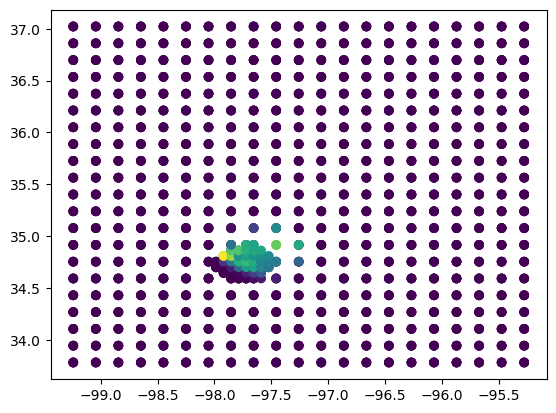

In [20]:
import matplotlib.pyplot as plt
plt.scatter(lon[index][:], lat[index][:],c= Hxf[index][:,3], )

# LETKF

In [9]:
#!/usr/bin/env python
import sys
import os
import numpy as N
import datetime as DT 
from netCDF4 import *
import pyDart
from pyDart import dll_2_dxy
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *
import state_vector as state
import pickle
import json
# Fortran functions
sys.path.append( "./fsrc" )
from fpython2 import fstate


In [ ]:
python letkf.py --exper RUN_LETKF/RUN_LETKF.exp --time 2003,05,08,21,00,00 --nthreads 1

In [8]:

#-------------------------------------------------------------------------------
# Default values 

_missing_value = 9900000000.
_time_units    = 'seconds since 1970-01-01 00:00:00'
_calendar      = 'standard'

debug  = False
_update_theta = 1
_variable_dbz_error = False

#-------------------------------------------------------------------------------
# Run parameters for the filter

obs_diag = {11: ["VR"], 12:["DBZ"]}

#-------------------------------------------------------------------------------
def getIndexEqual(field, value):
    return ( field == value )

#-------------------------------------------------------------------------------
def getIndexGT(field, value):
    return ( field > value )

#-------------------------------------------------------------------------------
def getIndexLT(field, value):
    return ( field < value )

########################################################################################################################
#
# Main program
me=True
if me==True:

  stime = timer()
  now = DT.datetime.now()

  print("----------------------------------------------------------------------\n")
  print("              BEGIN PROGRAM LETKF                                     \n ")
  print(("  WALLCLOCK START TIME:  %s \n" % now.strftime("%Y-%m-%d %H:%M")))  
  print("  --------------------------------------------------------------------\n")
  
# Create timers for the code...

  timeFilter   = myTimer(name = "Filter")
  timeIO       = myTimer(name = "I/O")
  timeMain     = myTimer(name = "Program")
  timeHxF      = myTimer(name = "HxF")
  
# Time the data assimilation

  timeMain.start()

#-------------------------------------------------------------------------------
# Parse input command options

#   parser = OptionParser()
#   parser.add_option("-f", "--file",      dest="file",     type="string", help = "Priors netCDF file")
#   parser.add_option("-t", "--time",      dest="time",     type="string", help = "Analysis time in YYYY,MM,DD,HH,MM,SS")
#   parser.add_option("-e", "--exper",     dest="exper",    type="string", help = "experiment run file created to store database info")
#   parser.add_option(      "--nthreads",  dest="nthreads", type="int",    help = "Number of threads for LETKF computation")
#   parser.add_option(      "--outl",      dest="outl",     type="int",    help = "Outlier threshold for observations")
#   parser.add_option(      "--saveW",     dest="saveW",    default=False, help = "Save LETKF weights...", action="store_true")
#   parser.add_option(      "--readW",     dest="readW",    default=False, help = "Read LETKF weights...", action="store_true")
#   parser.add_option(      "--noupdate",  dest="noupdate", default=False, help = "Do not update variables", action="store_true")
#   parser.add_option(      "--aInflate",  dest="ainflate",  type = "int",   help = "Sets type of adaptive inflation (0,1,2,3)", default=None)
#   parser.add_option(      "--HF",        dest="HF",        type = "int",   help = "Sets up writeback skip for HF filter", default=None)
  
#   (options, args) = parser.parse_args()
    
# python letkf.py --exper RUN_LETKF/RUN_LETKF.exp --time 2003,05,08,21,05,00 --nthreads 1  --aInflate 1
#-------------------------------------------------------------------------------  
# Get experiment file
  with open('DBZ_VR/DBZ_VR.exp', 'rb') as p:
        exper = json.load(p)
      
  # if options.exper == None:
  #   print("\n --> LETKF:  No experiment's run filename specified, exiting....\n")
  #   parser.print_help()
  #   sys.exit(-1)
  # else:
  #   with open(options.exper, 'rb') as p:
  #       exper = json.load(p)

#-------------------------------------------------------------------------------
# Get the time stamp
  time = '2024,05,08,20,00,00'.split(",")  
  # if options.time == None:
  #   print("\n --> LETKF:  No analysis time specified, exiting....\n")
  #   parser.print_help()
  #   sys.exit(-1)
  # else:
  #   time = options.time.split(",")
    
#-------------------------------------------------------------------------------
# The rest of the input is options - so set parameters based on what is in the experiment data base

  mpass             = exper['DA_PARAMS']['mpass']
  writeFcstMean     = exper['DA_PARAMS']['writeFcstMean']
  writeAnalMean     = exper['DA_PARAMS']['writeAnalMean']
  saveWeights       = exper['DA_PARAMS']['saveWeights']
  readWeights       = exper['DA_PARAMS']['readWeights']
  rhoriz            = exper['DA_PARAMS']['rhoriz']
  rvert             = exper['DA_PARAMS']['rvert']
  rtime             = exper['DA_PARAMS']['rtime']
  cutoff            = exper['DA_PARAMS']['cutoff']
  zcutoff           = exper['DA_PARAMS']['zcutoff']
  inflate           = exper['DA_PARAMS']['inflate']
  print_state_stats = exper['DA_PARAMS']['print_state_stats']
  path              = exper['base_path']

#-------------------------------------------------------------------------------
# Parallel Threading
  nthreads=8

  # if options.nthreads != None:
  #   nthreads = options.nthreads
  #   print(("\n --> LETKF:  Number of threads requested is from command line:  %d" % nthreads))
  # else:
  #   nthreads = exper['DA_PARAMS']['nthreads']
  #   print(("\n --> LETKF:  Number of threads requested is from EXPER file:  %d" % nthreads))
    

#-------------------------------------------------------------------------------
#  Priors file
  print("\n --> LETKF:  No netCDF Priors file specified, using default priors file")
  ftime      = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
  prior_file = os.path.join(path, "Prior_%s.nc" % ftime.strftime("%Y-%m-%d_%H:%M:%S"))
  if os.path.isfile(prior_file):
    print(("\n --> LETKF:  Using prior file:  %s\n" % prior_file))

  # if options.file == None:
  #   print("\n --> LETKF:  No netCDF Priors file specified, using default priors file")
  #   ftime      = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
  #   prior_file = os.path.join(path, "Prior_%s.nc" % ftime.strftime("%Y-%m-%d_%H:%M:%S"))
  #   if os.path.isfile(prior_file):
  #     print(("\n --> LETKF:  Using prior file:  %s\n" % prior_file))
  #   else:
  #     print(("\n  --> LETKF:  Could not find prior file:  %s !!!!  Exiting LETKF...." % prior_file))
  #     parser.print_help()
  #     sys.exit(-1)
  # else:
  #   prior_file = options.file

#-------------------------------------------------------------------------------
# Inflation type
  aInflate = 1
  
  inflation_deltaT = exper['DA_PARAMS']['assim_window']
  dt = DT.timedelta(0,inflation_deltaT)
  in_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5])) - dt
  inflate_file = os.path.join(path, "Inflation_%s.nc" % in_time.strftime("%Y-%m-%d_%H:%M:%S"))
  print(("\n --> LETKF:  Trying to find inflation file: %s" % inflate_file))
  inflate_file_exists = False
  if os.path.isfile(inflate_file):
    inflate_file_exists = True
    print(("\n --> LETKF:  Using inflation file: %s" % inflate_file))
      
  # if options.ainflate:
  #   aInflate = options.ainflate
  # else:
  #   aInflate   = exper['DA_PARAMS']['aInflate']
    
  # if aInflate == 0:
  #   inflate_file_exists = False
  # else:
  #   inflation_deltaT = exper['DA_PARAMS']['assim_window']
  #   dt = DT.timedelta(0,inflation_deltaT)
  #   in_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5])) - dt
  #   inflate_file = os.path.join(path, "Inflation_%s.nc" % in_time.strftime("%Y-%m-%d_%H:%M:%S"))
  #   print(("\n --> LETKF:  Trying to find inflation file: %s" % inflate_file))
  #   if os.path.isfile(inflate_file):
  #     inflate_file_exists = True
  #     print(("\n --> LETKF:  Using inflation file: %s" % inflate_file))
  #   else:
  #     inflate_file_exists = False
  #     print("\n --> LETKF:  Could not find inflation file....none will be used.")

#-------------------------------------------------------------------------------
# LETKF Weight I/O flags
  saveWeights = exper['DA_PARAMS']['saveWeights']
  readWeights = exper['DA_PARAMS']['readWeights']
#   if options.saveW:
#     saveWeights = options.saveW
#     print(("\n --> LETKF: saveWeights is from command line:  %s" % saveWeights))
#   else:  
#     saveWeights = exper['DA_PARAMS']['saveWeights']
#     print(("\n --> LETKF: saveWeights is from EXPER file:  %s" % saveWeights))

#   if options.readW:
#     readWeights = options.readW
#     print(("\n --> LETKF: readWeights is from command line:  %s" % readWeights))
#   else:  
#     readWeights = exper['DA_PARAMS']['readWeights']
#     print(("\n --> LETKF: readWeights is from EXPER file:  %s" % readWeights))
   
# #-------------------------------------------------------------------------------
# # Update flag which is useful when debugging (does not overwrite files
  noUpdate = False
#   if options.noupdate:
#       noUpdate = options.noupdate
#       print("\n --> LETKF: noUpdate is set from command line:  No files will be written back")
#   else:
#       noUpdate = False

# #-------------------------------------------------------------------------------
# # outlier threshold
  outlier_threshold = exper['DA_PARAMS']['outlier']
#   if options.outl == None:
#     outlier_threshold = exper['DA_PARAMS']['outlier']
#     print(("\n --> LETKF: obs outlier is from EXPER file:  %d" % outlier_threshold))
#   else:
#     outlier_threshold = options.outl
#     print(("\n --> LETKF: obs outlier is from command line:  %d" % outlier_threshold))

########################################################################################################################
#
# Read in STATE VECTOR for ensemble
  
  timeIO.start()

  analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
  
  files, exper = ens.FindRestartFiles(exper, analysis_time, ret_DT=False)
  
  print(("\n  ---->LETKF:  Reading in model state for analysis at %s \n" %  (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
  
  state = ens.read_CM1_ens(files, exper, state_vector = None, DateTime=analysis_time, addmean=1)   
  ens.ens_CM1_coords(state)
  ens.ens_CM1_mean(state)
  
  tanalysis = date2num(analysis_time,units=_time_units,calendar=_calendar)
  
  print(("\n  ---->Analysis state read in for time %s " % (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
  print(("\n  ---->Analysis state universal time %f" % (tanalysis)))

  if debug:
    print("WARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("WARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("WARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("WARNING WARNING WARNING:  No files are written!!!!")
  else:
    if writeFcstMean:
      ens.write_CM1_ens(state, writeFcstMean=writeFcstMean, overwrite=True)
  
  timeIO.stop()
  
########################################################################################################################
#
# Read in observational priors

  timeHxF.start()
  
  analysis_sec = date2num(analysis_time,units=_time_units,calendar=_calendar)
     
  print(("\n  ----> LETKF:  Reading in Prior file:  %s \n" %  (prior_file)))
    
  kind, value, error, lat, lon, xob, yob, zob, tob, Hxf, Hxfbar, outlier = read_prior(analysis_time, file=prior_file, sort=True)

  nobs = Hxf.shape[0]
  ne   = Hxf.shape[1]
  
  if nobs == 0:  
    print(("\n  ----> LETKF:  Prior file is empty, exiting at analysis time %s \n" %  (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
    sys.exit(0)
  else:
    print(("\n  ----> LETKF:  Prior file has %d obs at analysis time %s \n" %  (nobs, analysis_time.strftime("%Y %m-%d %H:%M:%S"))))

    tob = N.array(tob - analysis_sec, dtype=N.float64)   # departure time for temporation localization

    if (outlier_threshold > 0):
      print(('\n  --> LETKF called with an outlier threshold of %d standard deviations' % outlier_threshold))

      mask  = N.where( outlier <= outlier_threshold, True, False )
      mask2 = N.where( kind == 11, True, False )
      print(("Mask before Vr mask:  ", N.count_nonzero(mask)))
      mask  = mask | mask2
      print(("Mask after Vr mask:  ", N.count_nonzero(mask)))

      kind   = kind[mask]
      value  = value[mask]
      error  = error[mask]
      tob    = tob[mask]
      xob    = xob[mask]
      yob    = yob[mask]
      zob    = zob[mask]
      Hxf    = Hxf[mask][:]
      Hxfbar = Hxfbar[mask]
      lat    = lat[mask]
      lon    = lon[mask]

      print('\n  >=====================================================================<')
      print(('\n  --> LETKF:  Number of total    obs = %d' % nobs))
      print(('\n  --> LETKF:  Number of rejected obs = %d' % (nobs - N.count_nonzero(mask) )))
      print(('\n  --> LETKF:  Max outlier: %f  Min outlier:  %f\n' % (outlier.max(), outlier.min())))
    
# Reset number of obs

      nobs = N.count_nonzero(mask)

# Change the dbz error threshold based on each obs innovation mean 

      if _variable_dbz_error:
          mask = N.where( kind == 12, True, False )
          print("  --> LETKF:  Variable dBZ error:  Number of dBZ observations is %d" % N.count_nonzero(mask))
          mask2 = N.where(value > 20., True, False)
          print("  --> LETKF:  Variable dBZ error:  Number of obs where value > 20  %d" % N.count_nonzero(mask2))
          mask  = mask & mask2
          print("  -->  LETKF:  Number of Priors where Obs > 20 and will have their values increased:  %d" % N.count_nonzero(mask))
          Hxfbar[mask] = Hxfbar[mask] + 10.
          Hxf[mask,:] = Hxf[mask,:] + 10.

# Recompute coordinate system of x/y's based from the SW corner (lat,lon) of model grid.
# The observations' new x/y's are then in the model's coordinate system relative to reference (lat,lon) of grid
# Need to do this again because of running-in-place for moving grids...

  xob, yob = pyDart.dll_2_dxy(state.late[0], lat, state.lone[0], lon, degrees=True)
  dep      = N.zeros(nobs)
  dep[:]   = value[:] - Hxfbar[:]
    
# Here we create the localization arrays

  rdiag    = N.array(error.reshape(nobs,1), order='F')
  rloc     = N.array(N.ones(nobs).reshape(nobs,1), order='F')

# Print some stats...

  print("\n  >==============================================================================================<")
  print(("\n  LETKF:  %s  Total number of observations:  %d" % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"),value.size)))
  print("\n  <==============================================================================================<")
  print("\n  LETKF:  Obs Space Diagnostic for forecast computed via Dowell and Wicker, MWR 2009, Additive Noise\n")
  print("\n  LETKF:  Obs Std  |  Root-Mean-Sq-Error  |    Bias    |  Spread (obsErr^2+Hxf_var^2)  |   Consistency Ratio")
  print("\n  >==============================================================================================<\n")

  for key in list(obs_diag.keys()):
    index_kind  = getIndexEqual(kind, key)
    d           = dep[index_kind]
    
    if obs_diag[key][0] == 'DBZ':

  # Non-zero dBZ obs
  
        index_dbz   = index_kind & getIndexGT(value, 0.1)

        if N.sum(index_dbz) > 0:
          ob_err      = error[index_dbz].mean()
          d           = dep[index_dbz]
          Hxftmp      = Hxf[index_dbz,:]
          Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
          inno_var    = N.mean((d - d.mean())**2)
          consi_ratio = (ob_err + Hxf_var) / inno_var

          print(("\n -->  LETKF:  %s  NOBS: %5.5d  %3.3s>0: %3.1f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"), N.sum(index_dbz), obs_diag[key][0], N.sqrt(ob_err), \
                   N.sqrt(inno_var), d.mean(), N.sqrt(ob_err + Hxf_var), consi_ratio)))
        else:
          print(("\n -->  LETKF:  %3.3s>0: is not present in observations" % (obs_diag[key][0])))

  # zero dBZ obs      

        index_dbz   = index_kind & getIndexLT(value, 0.1)
        if N.sum(index_dbz) > 0:
          ob_err      = error[index_dbz].mean()
          d           = dep[index_dbz]
          Hxftmp      = Hxf[index_dbz,:]
          Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
          inno_var    = N.mean((d - d.mean())**2)
          consi_ratio = (ob_err + Hxf_var) / inno_var
          print(("\n --> LETKF:%s  NOBS: %5.5d  %3.3s<0: %3.1f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"), N.sum(index_dbz), obs_diag[key][0], N.sqrt(ob_err), \
                   N.sqrt(inno_var), d.mean(), N.sqrt(ob_err + Hxf_var), consi_ratio)))
        else:
          print(("\n -->  LETKF:  %3.3s<=0: is not present in observations" % (obs_diag[key][0])))

  # other obs

    elif d.size > 0:

      ob_err      = error[index_kind].mean()
      d           = dep[index_kind]
      Hxftmp      = Hxf[index_kind,:]
      Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
      inno_var    = N.mean((d - d.mean())**2)
      consi_ratio = (ob_err + Hxf_var) / inno_var
      print(("\n -->  LETKF:  %s  NOBS: %5.5d    %3.3s: %3.1f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"), N.sum(index_kind), obs_diag[key][0], N.sqrt(ob_err), \
                   N.sqrt(inno_var), d.mean(), N.sqrt(ob_err + Hxf_var), consi_ratio)))
    else:
      print(("\n -->  LETKF:  %s is not present in observations" % (obs_diag[key][0])))

  print("\n  >============================================================================================<\n")

  timeHxF.stop()
  
#################################################################################################
#
# Adaptive inflation: read in or create dummy file....

  if aInflate == 0:   # just create a dummy array of ones...
    print("\n -->  LETKF:  Adaptive inflation is turned off....\n")
    inflate = N.ones((state.nz, state.ny, state.nx), order='F', dtype=N.float64)
  else:
    print("\n -->  LETKF:  Adaptive inflation is turned on....\n")
    if inflate_file_exists:
      print(("\n -->  LETKF:  Adaptive inflation is using prior file:  %s\n" % inflate_file))
      inflate = read_inflation_file(file=inflate_file)
    else:
      print("\n -->  LETKF: Adaptive inflation cannot find the previous inflation file, initializing inflation array to 1.0 \n") 
      inflate = N.ones((state.nz, state.ny, state.nx), order='F', dtype=N.float64)
      
################################################################################################################################

# Begin LETKF analysis
 
  if print_state_stats: print_state_diagnostics(state, store=True)
  
  print("\n  >=======================  >>BEGIN FILTER<< ===========================================<\n")    

# Call the fortran letkf module

  timeFilter.start()

  if mpass == True:

    print("\n -->  LETKF:  MultiPASS algorithm turned on, assimilating VR THEN DBZ\n")
    for key in list(obs_diag.keys()):

      index_kind  = getIndexEqual(kind, key)
      if obs_diag[key][0] == "DBZ":  
        update_theta = 0
      else:
        update_theta = _update_theta

      if N.sum(index_kind) > 0:
        print(("\n-->  LETKF:  %d observations of %3.3s is now being assimilated!\n" % (N.sum(index_kind), obs_diag[key][0])))
        inflateN = fstate.compute_letkf(xob[index_kind], yob[index_kind], zob[index_kind], tob[index_kind], tanalysis,
                                        value[index_kind], Hxf[index_kind], dep[index_kind], rdiag[index_kind], rloc[index_kind], 
                                        rhoriz, rvert, rtime, nthreads, cutoff, zcutoff, update_theta, aInflate, inflate,
                                        saveWeights, readWeights)
      else:
        print(("\n -->  LETKF:%3.3s: NO OBSERVATIONS FOUND!\n" % (obs_diag[key][0])))

  else:

    print("\n -->  LETKF:ALL OBS TYPES BEING ASSIMULATED SIMULTANEOUSLY: MULTIPASS==False\n")
    update_theta = _update_theta
    inflateN = fstate.compute_letkf(xob, yob, zob, tob, tanalysis,
                                    value, Hxf, dep, rdiag, rloc, 
                                    rhoriz, rvert, rtime, nthreads, cutoff, zcutoff, update_theta, aInflate, inflate,
                                    saveWeights, readWeights)
                           
# # inflateN always has the adaptive inflation field produced by LETKF core. Write it out...

#   if aInflate > 0:
#     print(("\n -->  LETKF:  Adaptive Inflation stats:  Max AI:  %3.1f  Min AI %3.1f  Mean AI: %3.1f  StdDev:  %4.3f\n" % \
#         (inflateN.max(), inflateN.min(), inflateN.mean(), inflateN.std())))

#   InflationFile = write_inflation_file(inflateN,fstate.xc,fstate.yc,fstate.zc,analysis_time)
#   newInflationFile = os.path.join(path, InflationFile)
#   os.rename(InflationFile, newInflationFile)
#   print(("\n -->  LETKF:  Moved %s file to directory %s" %(InflationFile, path)))

# # If saveWeights == True, rename the netCDF4 file dumped out by the fortran code

#   if saveWeights:
#     rename_weight_file(analysis_time)

#   timeFilter.stop()

#   print("\n  >=======================  >>END FILTER<< ===========================================<\n")    

#   if print_state_stats: print_state_diagnostics(state, header=True)   
  
# # Write out model state
  
#   timeIO.start()

# # Write ensemble back out

#   if debug:
#     print("\nWARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
#     print("\nWARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
#     print("\nWARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
#     print("\nWARNING WARNING WARNING:  STATE DATA IS NOT WRITTEN BACK OUT!")
#   elif noUpdate:
#     print("\n -->  LETKF:  NO UPDATE FLAG is TRUE....state data will not be written back out!")
#   else:
#     print("\n -->  LETKF:  state data now written back out!")
#     ens.write_CM1_ens(state, writeEns=True, writeAnalMean=writeAnalMean, overwrite=False)#, HF=options.HF)
  
#   timeIO.stop()
  
# # Print out specific timing information

#   timeHxF.printit("")
#   timeFilter.printit("")
#   timeIO.printit("")
  
#   timeMain.stop()
#   timeMain.printit("")

# # Print out Wallclock time for LETKF

#   now = DT.datetime.now()

#   print("\n  ----------------------------------------------------------------------")
#   print("\n                END PROGRAM LETKF                                        ")
#   print(("\n  WALLCLOCK END TIME:  %s \n" % now.strftime("%Y-%m-%d %H:%M")))  
#   print("\n  -----------------------------------------------------------------------\n")


----------------------------------------------------------------------

              BEGIN PROGRAM LETKF                                     
 
  WALLCLOCK START TIME:  2025-04-03 23:56 

  --------------------------------------------------------------------


 --> LETKF:  No netCDF Priors file specified, using default priors file

 --> LETKF:  Using prior file:  /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:00:00.nc


 --> LETKF:  Trying to find inflation file: /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Inflation_2024-05-08_19:59:30.nc

 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 2700 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/member001/cm1rst_000009.nc

  ---->LETKF:  Reading in model state for analysis at 2024 05-08 20:00:00 


 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_

NameError: name 'fstate' is not defined

In [11]:
index_kind  = getIndexEqual(kind, 11)

In [13]:
value[index_kind]

masked_array(data=[ 4.52374311,  6.01211415,  6.85047665,  8.33634024,
                    4.96774367,  6.07902327,  7.29477135,  9.61311077,
                    9.4009037 , 11.16060393, 11.95807832, 13.06172338,
                    5.3660868 ,  6.68399011,  7.09700164,  8.14800688,
                    3.22938288,  5.61464968,  7.54449034, 10.75111367,
                    8.33284458, 11.25389444, 13.21546589, 16.00014901,
                    7.96150039,  9.69652308, 10.93417463, 12.2930178 ,
                    8.07646047,  9.9114899 , 11.26057194, 12.22568771,
                    7.09905546,  9.02461381, 10.48046281, 11.54426008,
                    5.65622932,  8.03630907,  9.59554331, 11.0089845 ,
                    8.59196898, 10.79744315, 12.43769454, 14.09272416,
                    6.90579599,  9.37691369, 11.72306518, 13.67337322,
                    8.44746829, 10.75824723, 12.28244672, 13.58922844,
                    9.02161934, 11.14450644, 12.71962458, 13.76954021,
      

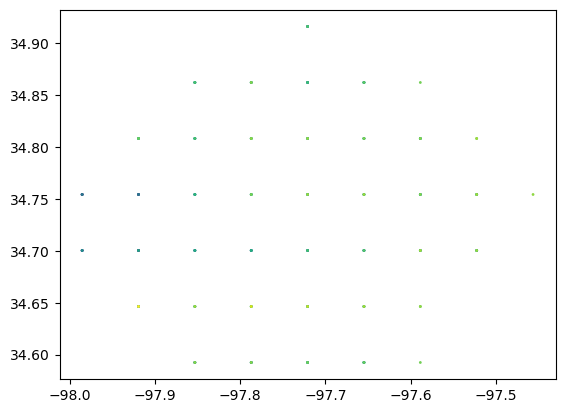

In [12]:
#P.scatter(lon[index_kind]/1000, lat[index_kind]/1000, c=value[index_kind], s=.5)
P.scatter(lon[index_kind], lat[index_kind], c=value[index_kind], s=1)
# P.xlim(0,140)
# P.ylim(0,140)

In [9]:
 kind, value, error, lat, lon, xob, yob, zob, tob, Hxf, Hxfbar, outlier = read_prior(analysis_time, file=prior_file, sort=True)

Prior obs file found, opening /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:00:00.nc 

Total number of obs in /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:00:00.nc file is 2049 



In [10]:
len(kind)

2049

In [11]:
ob_err      = error[index_kind].mean()
d           = dep[index_kind]
Hxftmp      = Hxf[index_kind,:]
Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
inno_var    = N.mean((d - d.mean())**2)
consi_ratio = (ob_err + Hxf_var) / inno_var

In [13]:
d

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan])

In [17]:
index_kind  = getIndexEqual(kind, 12)
Hxfbar[index_kind]

masked_array(data=[0., 0., 0., ..., 0., 0., 0.],
             mask=False,
       fill_value=1e+20)